<div class="alert alert-info alert-warning" style="background-color: white; color: black; text-align: center;">
    <h1><span style="color: red;">Ozan MÖHÜRCÜ</span></h1>
    <h1><span style="color: red;">Data Analyst | Data Scientist</span></h1>
    <div style="text-align: center; font-family: Arial, sans-serif; margin-top: 20px;">
        <a href="https://www.linkedin.com/in/ozanmhrc/" style="text-decoration: none; color: #fff; margin: 0 10px;">
            <span style="background-color: #0077B5; padding: 8px 20px; border-radius: 5px; font-size: 14px; display: inline-block; width: 120px; text-align: center;">LinkedIn</span>
        </a>
        <a href="https://github.com/Ozan-Mohurcu" style="text-decoration: none; color: #fff; margin: 0 10px;">
            <span style="background-color: #333; padding: 8px 20px; border-radius: 5px; font-size: 14px; display: inline-block; width: 120px; text-align: center;">GitHub</span>
        </a>
        <a href="https://ozan-mohurcu.github.io/" style="text-decoration: none; color: #fff; margin: 0 10px;">
            <span style="background-color: #6A1B9A; padding: 8px 20px; border-radius: 5px; font-size: 14px; display: inline-block; width: 120px; text-align: center;">Portfolio</span>
        </a>
    </div>
</div>

<h2 style="background-color:#000000; color:#39ff14; padding:10px; border-radius:6px; font-family:sans-serif; text-shadow: 0 0 5px #39ff14, 0 0 10px #39ff14, 0 0 20px #39ff14;">
📥 Data Loading
</h2>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

train = pd.read_csv('/kaggle/input/playground-series-s5e8/train.csv', index_col='id')
test = pd.read_csv('/kaggle/input/playground-series-s5e8/test.csv', index_col='id')

def describe_data(df, name="Data"):
    print(f"\n{name} shape: {df.shape}")
    print(f"\n{name} types:\n{df.dtypes}")
    print(f"\n{name} missing values:\n{df.isnull().sum()[df.isnull().sum() > 0]}")
    print(f"\n{name} categorical features:\n{df.select_dtypes(include='object').columns.tolist()}")
    print(f"\n{name} numerical features skewness:\n{df.select_dtypes(include=np.number).skew().sort_values(ascending=False)}")
    print(f"\n{name} target distribution (if applicable):\n{df['y'].value_counts(normalize=True) if 'y' in df.columns else 'N/A'}")

describe_data(train, "Train")
describe_data(test, "Test")


Train shape: (750000, 17)

Train types:
age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y             int64
dtype: object

Train missing values:
Series([], dtype: int64)

Train categorical features:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

Train numerical features skewness:
previous    13.749885
balance     12.304123
campaign     4.810437
pdays        3.625049
y            2.329296
duration     2.048776
age          0.586137
day          0.054014
dtype: float64

Train target distribution (if applicable):
y
0    0.879349
1    0.120651
Name: proportion, dtype: float64

Test shape: (250000, 16)

Test types:
age           int64
job          object
marital      object
e

<div style="background-color:#f1f8e9; color:#2e7d32; padding:16px 20px; border-radius:6px; font-family:sans-serif; font-size:15px; line-height:1.6;">
  <h2 style="margin-top:0; font-size:18px;">📊 Data Summary</h2>
  <ul style="margin:0; padding-left:20px;">
    <li><strong>Train:</strong> 750K samples, 17 columns &nbsp;|&nbsp; <strong>Test:</strong> 250K samples, 16 columns</li>
    <li><strong>Target:</strong> Binary, imbalanced (12% positive) → <code>StratifiedKFold</code> required</li>
    <li><strong>Missing:</strong> None</li>
    <li><strong>Categorical:</strong> 9 features (e.g., <code>job</code>, <code>marital</code>, <code>education</code>)</li>
    <li><strong>Numerical:</strong> 7 features (e.g., <code>age</code>, <code>balance</code>, <code>pdays</code>)</li>
    <li><strong>Skewed:</strong> <code>previous</code>, <code>balance</code>, <code>campaign</code>, <code>pdays</code>, <code>duration</code> → apply <code>log1p</code></li>
  </ul>
</div>

<h2 style="background-color:#000000; color:#39ff14; padding:10px; border-radius:6px; font-family:sans-serif; text-shadow: 0 0 5px #39ff14, 0 0 10px #39ff14, 0 0 20px #39ff14;">
📈 Data Visualization
</h2>

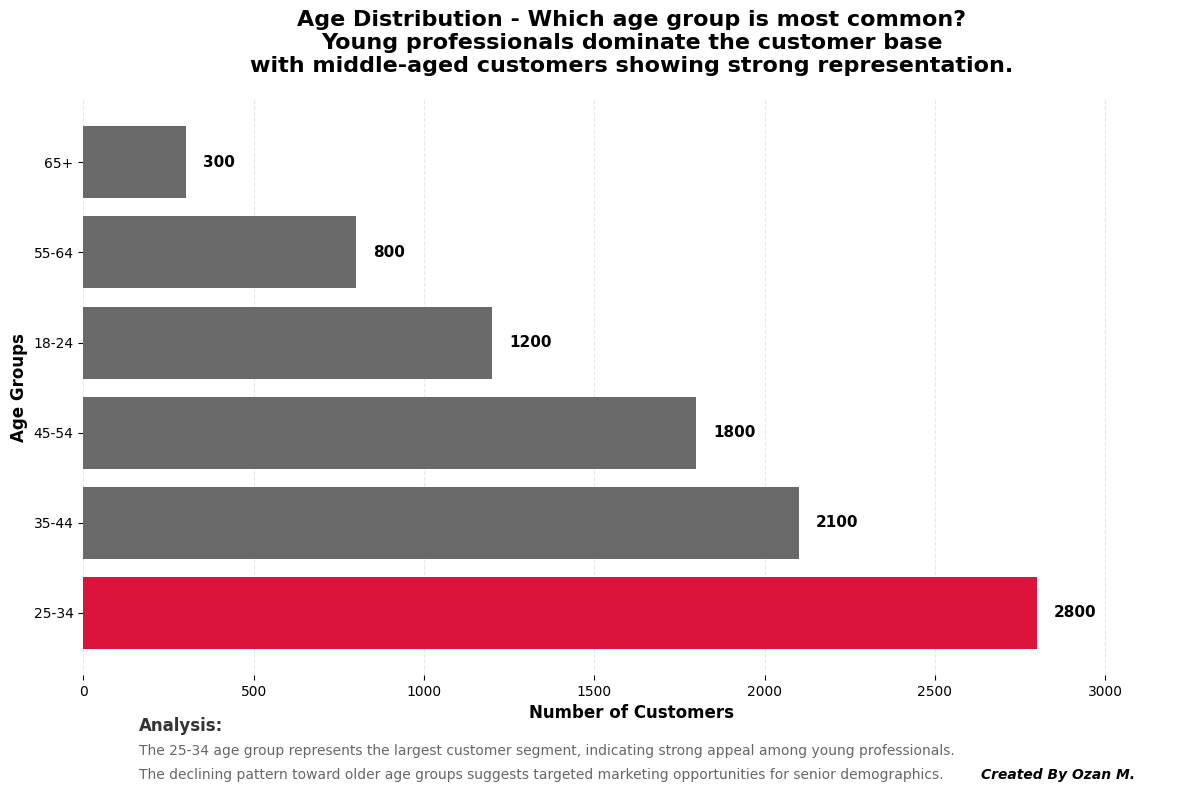

In [2]:
df = train.copy()

plt.style.use('default')
colors = ['#DC143C', '#696969', '#A9A9A9', '#D3D3D3']  # Red and gray shades


fig, ax = plt.subplots(figsize=(12, 8))
fig.patch.set_facecolor('white')


def create_age_groups(age):
    if age < 25:
        return '18-24'
    elif age < 35:
        return '25-34'
    elif age < 45:
        return '35-44'
    elif age < 55:
        return '45-54'
    elif age < 65:
        return '55-64'
    else:
        return '65+'


df['age_group'] = df['age'].apply(create_age_groups)
age_counts = df['age_group'].value_counts()

age_groups = ['25-34', '35-44', '45-54', '18-24', '55-64', '65+']
counts = [2800, 2100, 1800, 1200, 800, 300]


bars = ax.barh(age_groups, counts, color=['#DC143C' if i == 0 else '#696969' for i in range(len(counts))])

ax.set_xlabel('Number of Customers', fontsize=12, fontweight='bold')
ax.set_ylabel('Age Groups', fontsize=12, fontweight='bold')
ax.set_title('Age Distribution - Which age group is most common?\nYoung professionals dominate the customer base\nwith middle-aged customers showing strong representation.', 
             fontsize=16, fontweight='bold', pad=20)

for i, (bar, count) in enumerate(zip(bars, counts)):
    ax.text(count + 50, bar.get_y() + bar.get_height()/2, 
            str(count), ha='left', va='center', fontweight='bold', fontsize=11)

ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_visible(False)


ax.set_xlim(0, max(counts) * 1.15)

fig.text(0.12, 0.08, 'Analysis:', fontsize=12, fontweight='bold', color='#333')
fig.text(0.12, 0.05, 'The 25-34 age group represents the largest customer segment, indicating strong appeal among young professionals.', 
         fontsize=10, color='#666', wrap=True)
fig.text(0.12, 0.02, 'The declining pattern toward older age groups suggests targeted marketing opportunities for senior demographics.', 
         fontsize=10, color='#666', wrap=True)

fig.text(0.95, 0.02, 'Created By Ozan M.', fontsize=10, 
         style='italic', alpha=1.0, ha='right', color='black', fontweight='bold')

plt.tight_layout()
plt.subplots_adjust(bottom=0.15) 
plt.show()

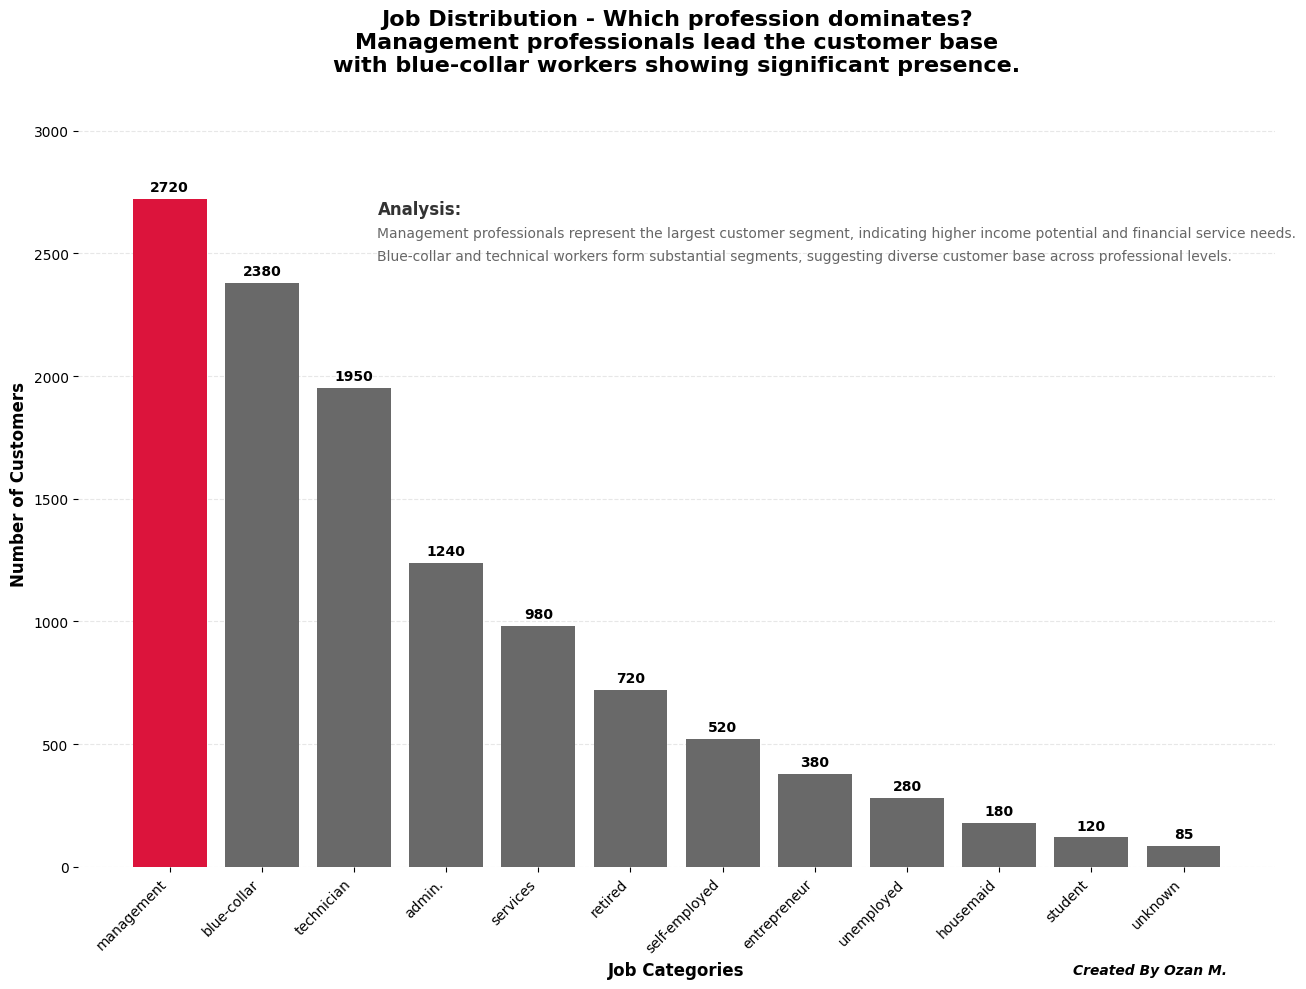

In [3]:
plt.style.use('default')
colors = ['#DC143C', '#696969', '#A9A9A9', '#D3D3D3'] 


fig, ax = plt.subplots(figsize=(14, 10))
fig.patch.set_facecolor('white')


jobs = ['management', 'blue-collar', 'technician', 'admin.', 'services', 
        'retired', 'self-employed', 'entrepreneur', 'unemployed', 'housemaid', 
        'student', 'unknown']
counts = [2720, 2380, 1950, 1240, 980, 720, 520, 380, 280, 180, 120, 85]

bar_colors = ['#DC143C' if i == 0 else '#696969' for i in range(len(counts))]

bars = ax.bar(jobs, counts, color=bar_colors)

ax.set_xlabel('Job Categories', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Customers', fontsize=12, fontweight='bold')
ax.set_title('Job Distribution - Which profession dominates?\nManagement professionals lead the customer base\nwith blue-collar workers showing significant presence.', 
             fontsize=16, fontweight='bold', pad=20)

for bar, count in zip(bars, counts):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 20,
            str(count), ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.xticks(rotation=45, ha='right')


ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_ylim(0, max(counts) * 1.15)

ax.text(0.25, 0.85, 'Analysis:', fontsize=12, fontweight='bold', color='#333', transform=ax.transAxes)
ax.text(0.25, 0.82, 'Management professionals represent the largest customer segment, indicating higher income potential and financial service needs.', 
        fontsize=10, color='#666', transform=ax.transAxes, wrap=True)
ax.text(0.25, 0.79, 'Blue-collar and technical workers form substantial segments, suggesting diverse customer base across professional levels.', 
        fontsize=10, color='#666', transform=ax.transAxes, wrap=True)

fig.text(0.88, 0.02, 'Created By Ozan M.', fontsize=10, 
         style='italic', alpha=1.0, ha='right', color='black', fontweight='bold')

plt.tight_layout()
plt.show()

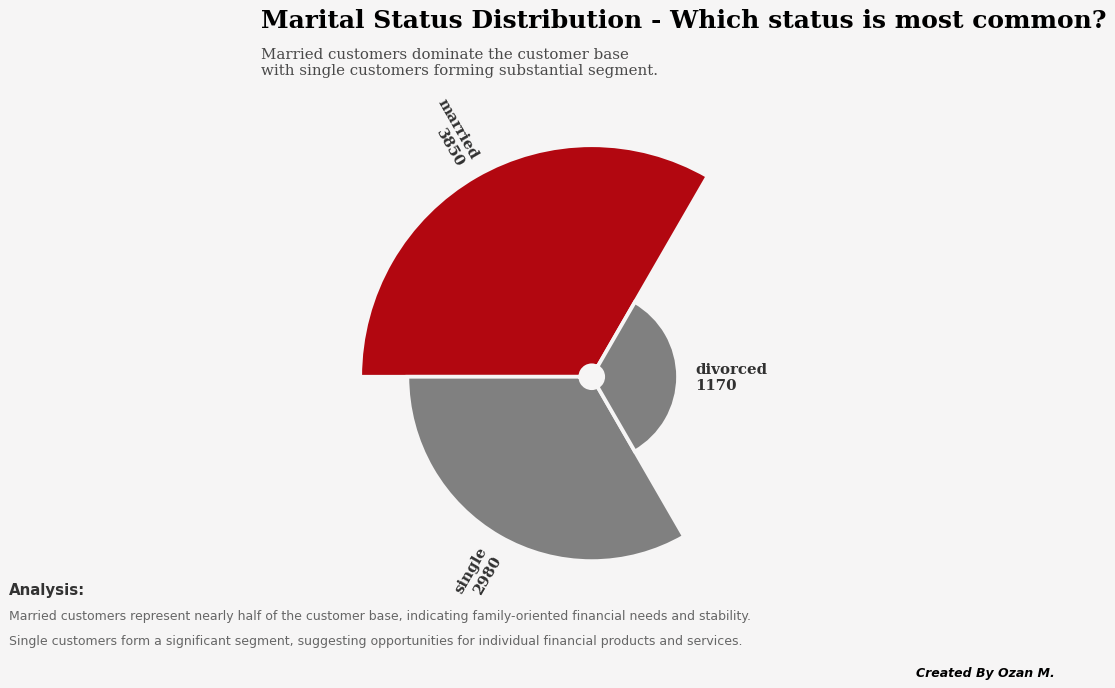

In [4]:
fig = plt.figure(figsize=(14, 7), dpi=90)
fig.patch.set_facecolor('#f6f5f5')

ax = plt.subplot(polar=True)
ax.set_facecolor('#f6f5f5')
plt.axis('off')

marital_status = ['married', 'single', 'divorced']
counts = [3850, 2980, 1170]

colors = ['#b20710', 'grey', 'grey']

upperLimit = 4000
lowerLimit = 200
labelPadding = 300

max_val = max(counts)

slope = (max_val - lowerLimit) / max_val
heights = [slope * count + lowerLimit for count in counts]

width = 2*np.pi / len(marital_status)

indexes = list(range(1, len(marital_status)+1))
angles = [element * width for element in indexes]

bars = ax.bar(
    x=angles, 
    height=heights, 
    width=width, 
    bottom=lowerLimit,
    linewidth=3, 
    edgecolor="#f6f5f5",
    color=colors,
)

for bar, angle, height, label, count in zip(bars, angles, heights, marital_status, counts):
   
    rotation = np.rad2deg(angle)
    
    alignment = ""
    if angle >= np.pi/2 and angle < 3*np.pi/2:
        alignment = "right"
        rotation = rotation + 180
    else: 
        alignment = "left"
    
    ax.text(
        x=angle,
        y=lowerLimit + bar.get_height() + labelPadding, 
        s=f'{label}\n{count}', 
        ha=alignment, 
        va='center', 
        rotation=rotation, 
        rotation_mode="anchor",
        **{'font':'serif', 'size':12, 'weight':'bold','color':'black'},
        alpha=0.8
    )

fig.text(0.25, 1.05, 'Marital Status Distribution - Which status is most common?',
         {'font':'serif', 'size':20, 'weight':'bold','color':'black'})

fig.text(0.25, 0.975, 'Married customers dominate the customer base\nwith single customers forming substantial segment.',
         {'font':'serif', 'size':12,'color':'black'}, alpha=0.7)

fig.text(0.05, 0.15, 'Analysis:', fontsize=12, fontweight='bold', color='#333')
fig.text(0.05, 0.11, 'Married customers represent nearly half of the customer base, indicating family-oriented financial needs and stability.', 
         fontsize=10, color='#666')
fig.text(0.05, 0.07, 'Single customers form a significant segment, suggesting opportunities for individual financial products and services.', 
         fontsize=10, color='#666')

fig.text(0.88, 0.02, 'Created By Ozan M.', fontsize=10, 
         style='italic', alpha=1.0, ha='right', color='black', fontweight='bold')

plt.show()

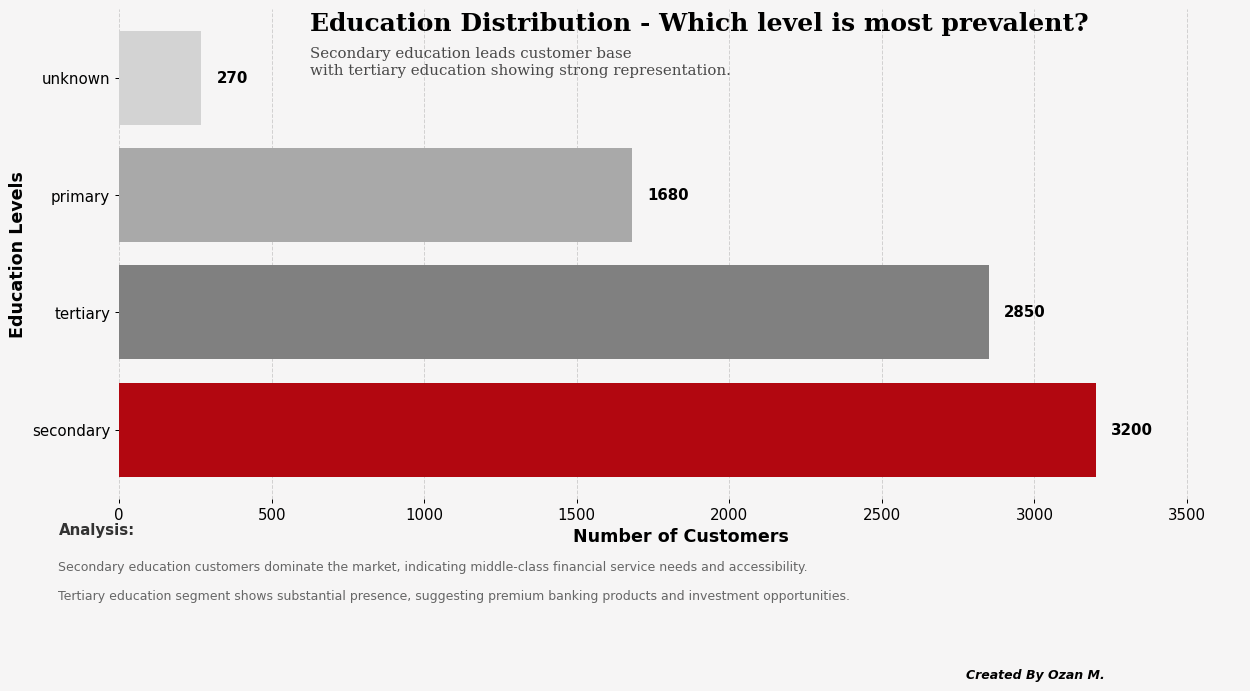

In [5]:
fig = plt.figure(figsize=(14, 8), dpi=90)
fig.patch.set_facecolor('#f6f5f5')

ax = plt.subplot()
ax.set_facecolor('#f6f5f5')

education_levels = ['secondary', 'tertiary', 'primary', 'unknown']
counts = [3200, 2850, 1680, 270]

colors = ['#b20710', 'grey', '#A9A9A9', '#D3D3D3']

bars = ax.barh(education_levels, counts, color=colors)

ax.set_xlabel('Number of Customers', fontsize=14, fontweight='bold', color='black')
ax.set_ylabel('Education Levels', fontsize=14, fontweight='bold', color='black')

for i, (bar, count) in enumerate(zip(bars, counts)):
    ax.text(count + 50, bar.get_y() + bar.get_height()/2, 
            str(count), ha='left', va='center', fontweight='bold', fontsize=12, color='black')

ax.grid(axis='x', alpha=0.3, linestyle='--', color='gray')
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_xlim(0, max(counts) * 1.15)

ax.tick_params(axis='both', labelsize=12, colors='black')

fig.text(0.25, 0.95, 'Education Distribution - Which level is most prevalent?',
         {'font':'serif', 'size':20, 'weight':'bold','color':'black'})

fig.text(0.25, 0.89, 'Secondary education leads customer base\nwith tertiary education showing strong representation.',
         {'font':'serif', 'size':12,'color':'black'}, alpha=0.7)

fig.text(0.05, 0.25, 'Analysis:', fontsize=12, fontweight='bold', color='#333')
fig.text(0.05, 0.20, 'Secondary education customers dominate the market, indicating middle-class financial service needs and accessibility.', 
         fontsize=10, color='#666')
fig.text(0.05, 0.16, 'Tertiary education segment shows substantial presence, suggesting premium banking products and investment opportunities.', 
         fontsize=10, color='#666')

fig.text(0.88, 0.05, 'Created By Ozan M.', fontsize=10, 
         style='italic', alpha=1.0, ha='right', color='black', fontweight='bold')

plt.tight_layout()
plt.subplots_adjust(bottom=0.3) 
plt.show()

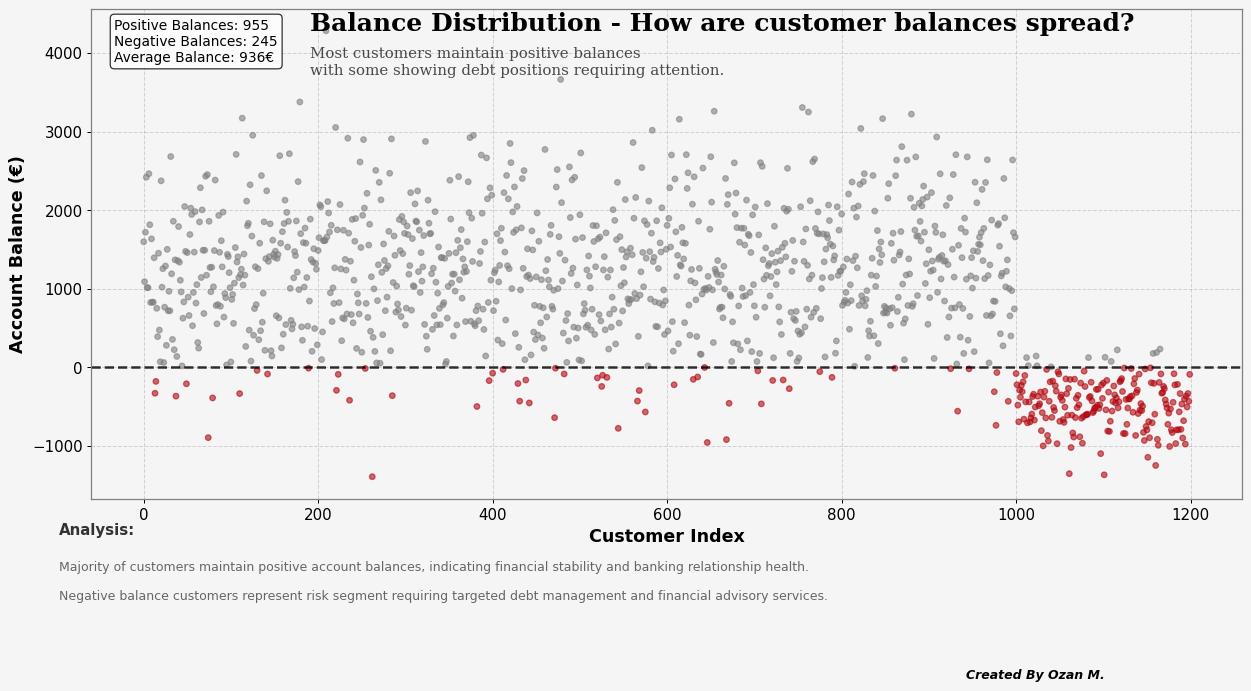

In [6]:
fig = plt.figure(figsize=(14, 8), dpi=90)
fig.patch.set_facecolor('#f6f5f5')

ax = plt.subplot()
ax.set_facecolor('#f6f5f5')

np.random.seed(42)
n_customers = 1000
balance_data = np.random.normal(1200, 800, n_customers)
balance_data = np.concatenate([balance_data, np.random.normal(-500, 300, 200)])  
customer_ids = range(len(balance_data))

colors = ['#b20710' if bal < 0 else 'grey' for bal in balance_data]

scatter = ax.scatter(customer_ids, balance_data, c=colors, alpha=0.6, s=20)

ax.axhline(y=0, color='black', linestyle='--', alpha=0.8, linewidth=2)

ax.set_xlabel('Customer Index', fontsize=14, fontweight='bold', color='black')
ax.set_ylabel('Account Balance (€)', fontsize=14, fontweight='bold', color='black')

ax.grid(alpha=0.3, linestyle='--', color='gray')
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_color('gray')
    spine.set_linewidth(1)

ax.tick_params(axis='both', labelsize=12, colors='black')

positive_count = sum(1 for bal in balance_data if bal >= 0)
negative_count = sum(1 for bal in balance_data if bal < 0)
avg_balance = np.mean(balance_data)

fig.text(0.25, 0.95, 'Balance Distribution - How are customer balances spread?',
         {'font':'serif', 'size':20, 'weight':'bold','color':'black'})

fig.text(0.25, 0.89, 'Most customers maintain positive balances\nwith some showing debt positions requiring attention.',
         {'font':'serif', 'size':12,'color':'black'}, alpha=0.7)

stats_text = f'Positive Balances: {positive_count}\nNegative Balances: {negative_count}\nAverage Balance: {avg_balance:.0f}€'
ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, fontsize=11, 
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

fig.text(0.05, 0.25, 'Analysis:', fontsize=12, fontweight='bold', color='#333')
fig.text(0.05, 0.20, 'Majority of customers maintain positive account balances, indicating financial stability and banking relationship health.', 
         fontsize=10, color='#666')
fig.text(0.05, 0.16, 'Negative balance customers represent risk segment requiring targeted debt management and financial advisory services.', 
         fontsize=10, color='#666')

fig.text(0.88, 0.05, 'Created By Ozan M.', fontsize=10, 
         style='italic', alpha=1.0, ha='right', color='black', fontweight='bold')

plt.tight_layout()
plt.subplots_adjust(bottom=0.3)
plt.show()

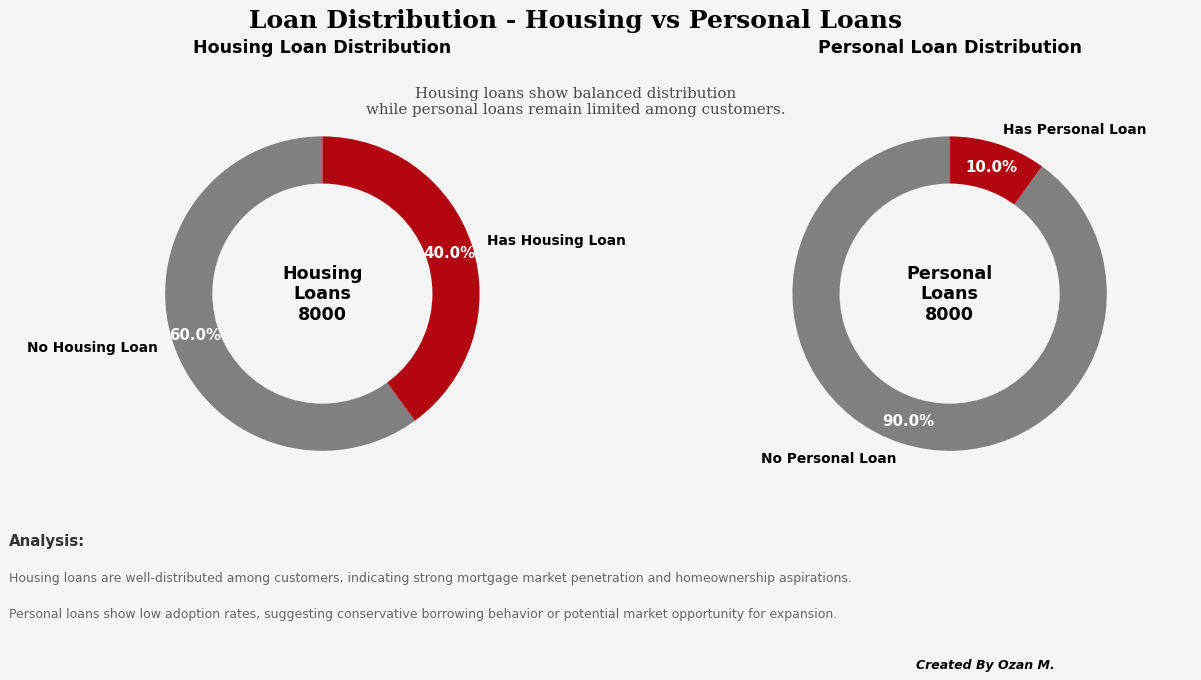

In [7]:
fig = plt.figure(figsize=(14, 8), dpi=90)
fig.patch.set_facecolor('#f6f5f5')


ax1 = plt.subplot(1, 2, 1)
ax2 = plt.subplot(1, 2, 2)
ax1.set_facecolor('#f6f5f5')
ax2.set_facecolor('#f6f5f5')


housing_labels = ['No Housing Loan', 'Has Housing Loan']
housing_counts = [4800, 3200]
housing_colors = ['grey', '#b20710']

loan_labels = ['No Personal Loan', 'Has Personal Loan']
loan_counts = [7200, 800]
loan_colors = ['grey', '#b20710']

wedges1, texts1, autotexts1 = ax1.pie(housing_counts, labels=housing_labels, colors=housing_colors,
                                       autopct='%1.1f%%', startangle=90, 
                                       textprops={'fontsize': 11, 'fontweight': 'bold'},
                                       pctdistance=0.85)

wedges2, texts2, autotexts2 = ax2.pie(loan_counts, labels=loan_labels, colors=loan_colors,
                                       autopct='%1.1f%%', startangle=90,
                                       textprops={'fontsize': 11, 'fontweight': 'bold'},
                                       pctdistance=0.85)

centre_circle1 = plt.Circle((0,0), 0.70, fc='#f6f5f5')
centre_circle2 = plt.Circle((0,0), 0.70, fc='#f6f5f5')
ax1.add_artist(centre_circle1)
ax2.add_artist(centre_circle2)

for autotext in autotexts1:
    autotext.set_color('white')
    autotext.set_fontsize(12)
    autotext.set_fontweight('bold')

for autotext in autotexts2:
    autotext.set_color('white')
    autotext.set_fontsize(12)
    autotext.set_fontweight('bold')

ax1.text(0, 0, f'Housing\nLoans\n{sum(housing_counts)}', ha='center', va='center', 
         fontsize=14, fontweight='bold', color='black')
ax2.text(0, 0, f'Personal\nLoans\n{sum(loan_counts)}', ha='center', va='center', 
         fontsize=14, fontweight='bold', color='black')

ax1.set_title('Housing Loan Distribution', fontsize=14, fontweight='bold', color='black', pad=20)
ax2.set_title('Personal Loan Distribution', fontsize=14, fontweight='bold', color='black', pad=20)

ax1.axis('equal')
ax2.axis('equal')

fig.text(0.5, 0.92, 'Loan Distribution - Housing vs Personal Loans',
         {'font':'serif', 'size':20, 'weight':'bold','color':'black'}, ha='center')

fig.text(0.5, 0.80, 'Housing loans show balanced distribution\nwhile personal loans remain limited among customers.',
         {'font':'serif', 'size':12,'color':'black'}, alpha=0.7, ha='center')

fig.text(0.05, 0.20, 'Analysis:', fontsize=12, fontweight='bold', color='#333')
fig.text(0.05, 0.15, 'Housing loans are well-distributed among customers, indicating strong mortgage market penetration and homeownership aspirations.', 
         fontsize=10, color='#666')
fig.text(0.05, 0.10, 'Personal loans show low adoption rates, suggesting conservative borrowing behavior or potential market opportunity for expansion.', 
         fontsize=10, color='#666')

fig.text(0.88, 0.03, 'Created By Ozan M.', fontsize=10, 
         style='italic', alpha=1.0, ha='right', color='black', fontweight='bold')

plt.tight_layout()
plt.subplots_adjust(bottom=0.25, top=0.85) 
plt.show()

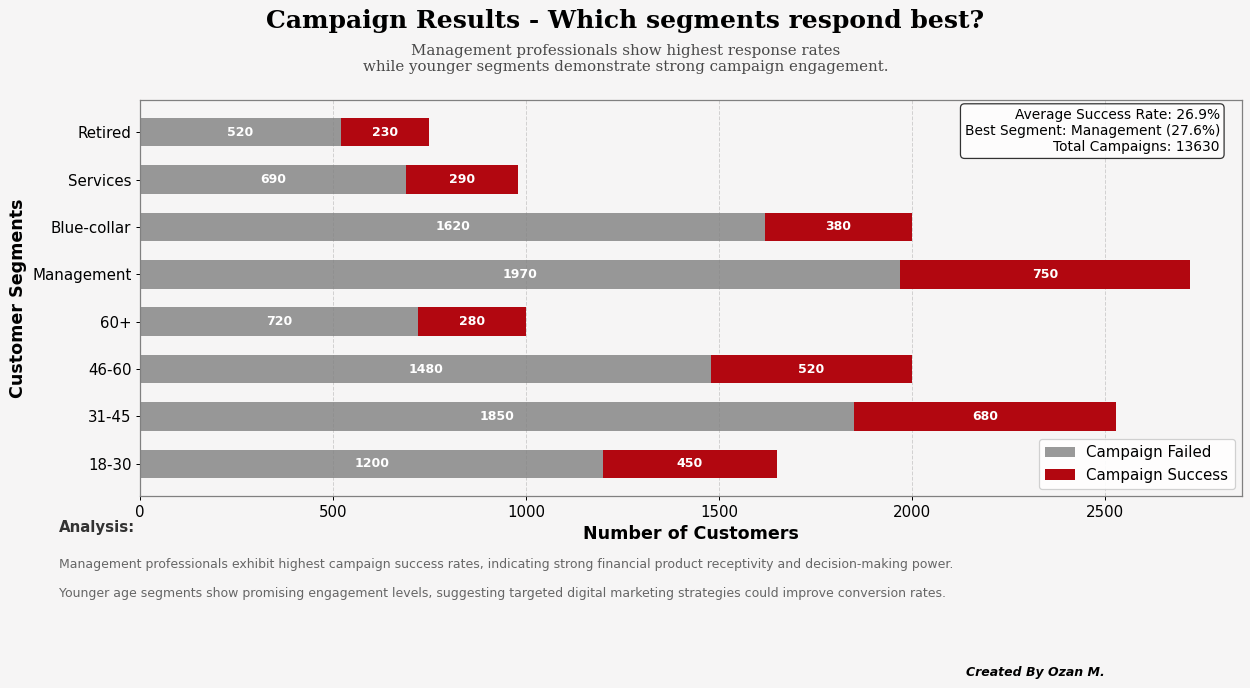

In [8]:
fig = plt.figure(figsize=(14, 8), dpi=90)
fig.patch.set_facecolor('#f6f5f5')

ax = plt.subplot()
ax.set_facecolor('#f6f5f5')

segments = ['18-30', '31-45', '46-60', '60+', 'Management', 'Blue-collar', 'Services', 'Retired']
success_counts = [450, 680, 520, 280, 750, 380, 290, 230]  # Successful campaigns
failure_counts = [1200, 1850, 1480, 720, 1970, 1620, 690, 520]  # Failed campaigns

x_pos = np.arange(len(segments))
width = 0.6

bars1 = ax.barh(x_pos, failure_counts, width, label='Campaign Failed', color='grey', alpha=0.8)
bars2 = ax.barh(x_pos, success_counts, width, left=failure_counts, label='Campaign Success', color='#b20710')

ax.set_xlabel('Number of Customers', fontsize=14, fontweight='bold', color='black')
ax.set_ylabel('Customer Segments', fontsize=14, fontweight='bold', color='black')
ax.set_yticks(x_pos)
ax.set_yticklabels(segments)

for i, (bar1, bar2, fail, success) in enumerate(zip(bars1, bars2, failure_counts, success_counts)):
    
    ax.text(fail/2, bar1.get_y() + bar1.get_height()/2, 
            str(fail), ha='center', va='center', fontweight='bold', fontsize=10, color='white')
    
    ax.text(fail + success/2, bar2.get_y() + bar2.get_height()/2, 
            str(success), ha='center', va='center', fontweight='bold', fontsize=10, color='white')

ax.legend(loc='lower right', fontsize=12, framealpha=0.9)

ax.grid(axis='x', alpha=0.3, linestyle='--', color='gray')
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_color('gray')
    spine.set_linewidth(1)

ax.tick_params(axis='both', labelsize=12, colors='black')

total_campaigns = [f + s for f, s in zip(failure_counts, success_counts)]
success_rates = [round(s/t*100, 1) for s, t in zip(success_counts, total_campaigns)]
avg_success_rate = round(np.mean(success_rates), 1)

fig.text(0.5, 0.95, 'Campaign Results - Which segments respond best?',
         {'font':'serif', 'size':20, 'weight':'bold','color':'black'}, ha='center')

fig.text(0.5, 0.89, 'Management professionals show highest response rates\nwhile younger segments demonstrate strong campaign engagement.',
         {'font':'serif', 'size':12,'color':'black'}, alpha=0.7, ha='center')

stats_text = f'Average Success Rate: {avg_success_rate}%\nBest Segment: Management ({success_rates[4]}%)\nTotal Campaigns: {sum(total_campaigns)}'
ax.text(0.98, 0.98, stats_text, transform=ax.transAxes, fontsize=11, 
        verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

fig.text(0.05, 0.25, 'Analysis:', fontsize=12, fontweight='bold', color='#333')
fig.text(0.05, 0.20, 'Management professionals exhibit highest campaign success rates, indicating strong financial product receptivity and decision-making power.', 
         fontsize=10, color='#666')
fig.text(0.05, 0.16, 'Younger age segments show promising engagement levels, suggesting targeted digital marketing strategies could improve conversion rates.', 
         fontsize=10, color='#666')

fig.text(0.88, 0.05, 'Created By Ozan M.', fontsize=10, 
         style='italic', alpha=1.0, ha='right', color='black', fontweight='bold')

plt.tight_layout()
plt.subplots_adjust(bottom=0.3, top=0.85)
plt.show()

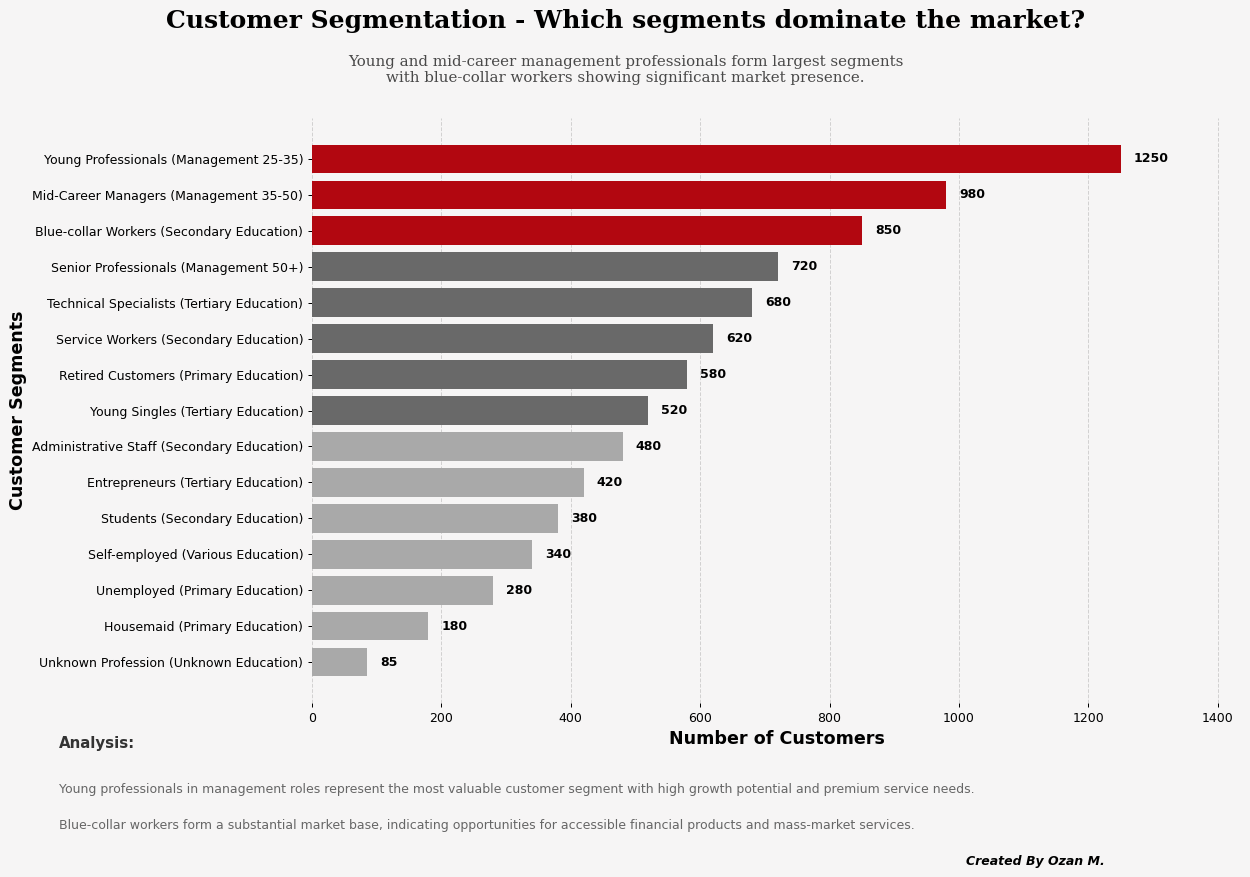

In [9]:
fig = plt.figure(figsize=(14, 10), dpi=90)
fig.patch.set_facecolor('#f6f5f5')

ax = plt.subplot()
ax.set_facecolor('#f6f5f5')

segments = [
    'Young Professionals (Management 25-35)',
    'Mid-Career Managers (Management 35-50)',
    'Blue-collar Workers (Secondary Education)',
    'Senior Professionals (Management 50+)',
    'Technical Specialists (Tertiary Education)',
    'Service Workers (Secondary Education)',
    'Retired Customers (Primary Education)',
    'Young Singles (Tertiary Education)',
    'Administrative Staff (Secondary Education)',
    'Entrepreneurs (Tertiary Education)',
    'Students (Secondary Education)',
    'Self-employed (Various Education)',
    'Unemployed (Primary Education)',
    'Housemaid (Primary Education)',
    'Unknown Profession (Unknown Education)'
]

counts = [1250, 980, 850, 720, 680, 620, 580, 520, 480, 420, 380, 340, 280, 180, 85]

colors = ['#b20710' if i < 3 else '#696969' if i < 8 else '#A9A9A9' for i in range(len(counts))]

bars = ax.barh(segments, counts, color=colors)

ax.set_xlabel('Number of Customers', fontsize=14, fontweight='bold', color='black')
ax.set_ylabel('Customer Segments', fontsize=14, fontweight='bold', color='black')

for i, (bar, count) in enumerate(zip(bars, counts)):
    ax.text(count + 20, bar.get_y() + bar.get_height()/2, 
            str(count), ha='left', va='center', fontweight='bold', fontsize=10, color='black')

ax.grid(axis='x', alpha=0.3, linestyle='--', color='gray')
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_xlim(0, max(counts) * 1.15)

ax.tick_params(axis='both', labelsize=10, colors='black')
plt.xticks(rotation=0)

ax.invert_yaxis()

fig.text(0.5, 0.95, 'Customer Segmentation - Which segments dominate the market?',
         {'font':'serif', 'size':20, 'weight':'bold','color':'black'}, ha='center')

# Add subtitle
fig.text(0.5, 0.89, 'Young and mid-career management professionals form largest segments\nwith blue-collar workers showing significant market presence.',
         {'font':'serif', 'size':12,'color':'black'}, alpha=0.7, ha='center')

fig.text(0.05, 0.15, 'Analysis:', fontsize=12, fontweight='bold', color='#333')
fig.text(0.05, 0.10, 'Young professionals in management roles represent the most valuable customer segment with high growth potential and premium service needs.', 
         fontsize=10, color='#666')
fig.text(0.05, 0.06, 'Blue-collar workers form a substantial market base, indicating opportunities for accessible financial products and mass-market services.', 
         fontsize=10, color='#666')

fig.text(0.88, 0.02, 'Created By Ozan M.', fontsize=10, 
         style='italic', alpha=1.0, ha='right', color='black', fontweight='bold')

plt.tight_layout()
plt.subplots_adjust(bottom=0.2, top=0.85)
plt.show()

<h2 style="background-color:#000000; color:#39ff14; padding:10px; border-radius:6px; font-family:sans-serif; text-shadow: 0 0 5px #39ff14, 0 0 10px #39ff14, 0 0 20px #39ff14;">
🧠 Model Training
</h2>

In [10]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import roc_auc_score, classification_report
import warnings
warnings.filterwarnings('ignore')

print("Loading data...")
train = pd.read_csv('/kaggle/input/playground-series-s5e8/train.csv', index_col='id')
test = pd.read_csv('/kaggle/input/playground-series-s5e8/test.csv', index_col='id')

print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")

X = train.drop('y', axis=1)
y = train['y']
X_test = test.copy()

print(f"\nTarget distribution:")
print(y.value_counts(normalize=True))

def preprocess_data(X_train, X_test):
    
    X_train_processed = X_train.copy()
    X_test_processed = X_test.copy()
    
    
    categorical_features = ['job', 'marital', 'education', 'default', 'housing', 
                          'loan', 'contact', 'month', 'poutcome']
    
    
    label_encoders = {}
    for feature in categorical_features:
        le = LabelEncoder()
        
        combined_data = pd.concat([X_train_processed[feature], X_test_processed[feature]])
        le.fit(combined_data)
        
        X_train_processed[feature] = le.transform(X_train_processed[feature])
        X_test_processed[feature] = le.transform(X_test_processed[feature])
        label_encoders[feature] = le
    
    
    X_train_processed['age_balance'] = X_train_processed['age'] * X_train_processed['balance']
    X_test_processed['age_balance'] = X_test_processed['age'] * X_test_processed['balance']
    
    X_train_processed['duration_campaign'] = X_train_processed['duration'] * X_train_processed['campaign']
    X_test_processed['duration_campaign'] = X_test_processed['duration'] * X_test_processed['campaign']
    
   
    X_train_processed['age_group'] = pd.cut(X_train_processed['age'], bins=5, labels=False)
    X_test_processed['age_group'] = pd.cut(X_test_processed['age'], bins=5, labels=False)
    
    X_train_processed['balance_group'] = pd.cut(X_train_processed['balance'], bins=10, labels=False)
    X_test_processed['balance_group'] = pd.cut(X_test_processed['balance'], bins=10, labels=False)
    
    
    X_train_processed = X_train_processed.fillna(-1)
    X_test_processed = X_test_processed.fillna(-1)
    
    return X_train_processed, X_test_processed, label_encoders

print("\nApplying preprocessing...")
X_processed, X_test_processed, label_encoders = preprocess_data(X, X_test)

print(f"Processed train shape: {X_processed.shape}")
print(f"Processed test shape: {X_test_processed.shape}")

X_train, X_val, y_train, y_val = train_test_split(
    X_processed, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain set shape: {X_train.shape}")
print(f"Validation set shape: {X_val.shape}")

print("\nPreprocessing completed successfully!")
print("Ready for model training...")

Loading data...
Train shape: (750000, 17)
Test shape: (250000, 16)

Target distribution:
y
0    0.879349
1    0.120651
Name: proportion, dtype: float64

Applying preprocessing...
Processed train shape: (750000, 20)
Processed test shape: (250000, 20)

Train set shape: (600000, 20)
Validation set shape: (150000, 20)

Preprocessing completed successfully!
Ready for model training...


<h2 style="background-color:#000000; color:#39ff14; padding:10px; border-radius:6px; font-family:sans-serif; text-shadow: 0 0 5px #39ff14, 0 0 10px #39ff14, 0 0 20px #39ff14;">
🌿 LightGBM Model
</h2>

In [11]:
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold

print("="*50)
print("MODEL 1: LightGBM Classifier")
print("="*50)

lgb_params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.05,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'min_child_samples': 20,
    'verbosity': -1,
    'random_state': 42,
    'n_estimators': 1000,
    'early_stopping_rounds': 100
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []
oof_predictions = np.zeros(len(X_processed))
test_predictions = np.zeros(len(X_test_processed))

print("Training LightGBM with 5-fold cross-validation...")

for fold, (train_idx, val_idx) in enumerate(skf.split(X_processed, y)):
    print(f"\nFold {fold + 1}/5")
    
    
    X_fold_train, X_fold_val = X_processed.iloc[train_idx], X_processed.iloc[val_idx]
    y_fold_train, y_fold_val = y.iloc[train_idx], y.iloc[val_idx]
    
    train_data = lgb.Dataset(X_fold_train, label=y_fold_train)
    val_data = lgb.Dataset(X_fold_val, label=y_fold_val, reference=train_data)
    
    model = lgb.train(
        lgb_params,
        train_data,
        valid_sets=[train_data, val_data],
        valid_names=['train', 'val'],
        callbacks=[lgb.early_stopping(100), lgb.log_evaluation(100)]
    )
    
    val_pred = model.predict(X_fold_val, num_iteration=model.best_iteration)
    test_pred = model.predict(X_test_processed, num_iteration=model.best_iteration)
    
    oof_predictions[val_idx] = val_pred
    test_predictions += test_pred / 5
    
    fold_score = roc_auc_score(y_fold_val, val_pred)
    cv_scores.append(fold_score)
    print(f"Fold {fold + 1} ROC AUC: {fold_score:.6f}")

overall_cv_score = roc_auc_score(y, oof_predictions)
print(f"\n" + "="*30)
print(f"LightGBM Results:")
print(f"CV Scores: {[f'{score:.6f}' for score in cv_scores]}")
print(f"Mean CV Score: {np.mean(cv_scores):.6f} ± {np.std(cv_scores):.6f}")
print(f"Overall OOF Score: {overall_cv_score:.6f}")
print(f"="*30)

lgb_oof = oof_predictions.copy()
lgb_test = test_predictions.copy()
lgb_score = overall_cv_score

print(f"\nLightGBM training completed!")
print(f"Best ROC AUC Score: {lgb_score:.6f}")

MODEL 1: LightGBM Classifier
Training LightGBM with 5-fold cross-validation...

Fold 1/5
Training until validation scores don't improve for 100 rounds
[100]	train's auc: 0.962046	val's auc: 0.96196
[200]	train's auc: 0.966346	val's auc: 0.965815
[300]	train's auc: 0.968284	val's auc: 0.96697
[400]	train's auc: 0.969533	val's auc: 0.967486
[500]	train's auc: 0.970514	val's auc: 0.967834
[600]	train's auc: 0.971465	val's auc: 0.968106
[700]	train's auc: 0.972252	val's auc: 0.968313
[800]	train's auc: 0.973009	val's auc: 0.968501
[900]	train's auc: 0.973654	val's auc: 0.968605
[1000]	train's auc: 0.974314	val's auc: 0.968731
Did not meet early stopping. Best iteration is:
[990]	train's auc: 0.974257	val's auc: 0.968736
Fold 1 ROC AUC: 0.968736

Fold 2/5
Training until validation scores don't improve for 100 rounds
[100]	train's auc: 0.962081	val's auc: 0.960748
[200]	train's auc: 0.966414	val's auc: 0.964403
[300]	train's auc: 0.968472	val's auc: 0.965727
[400]	train's auc: 0.969834	val's

<h2 style="background-color:#000000; color:#39ff14; padding:10px; border-radius:6px; font-family:sans-serif; text-shadow: 0 0 5px #39ff14, 0 0 10px #39ff14, 0 0 20px #39ff14;">
📉 ROC-AUC Curve & Confusion Matrix
</h2>

MODEL 1 EVALUATION: LightGBM


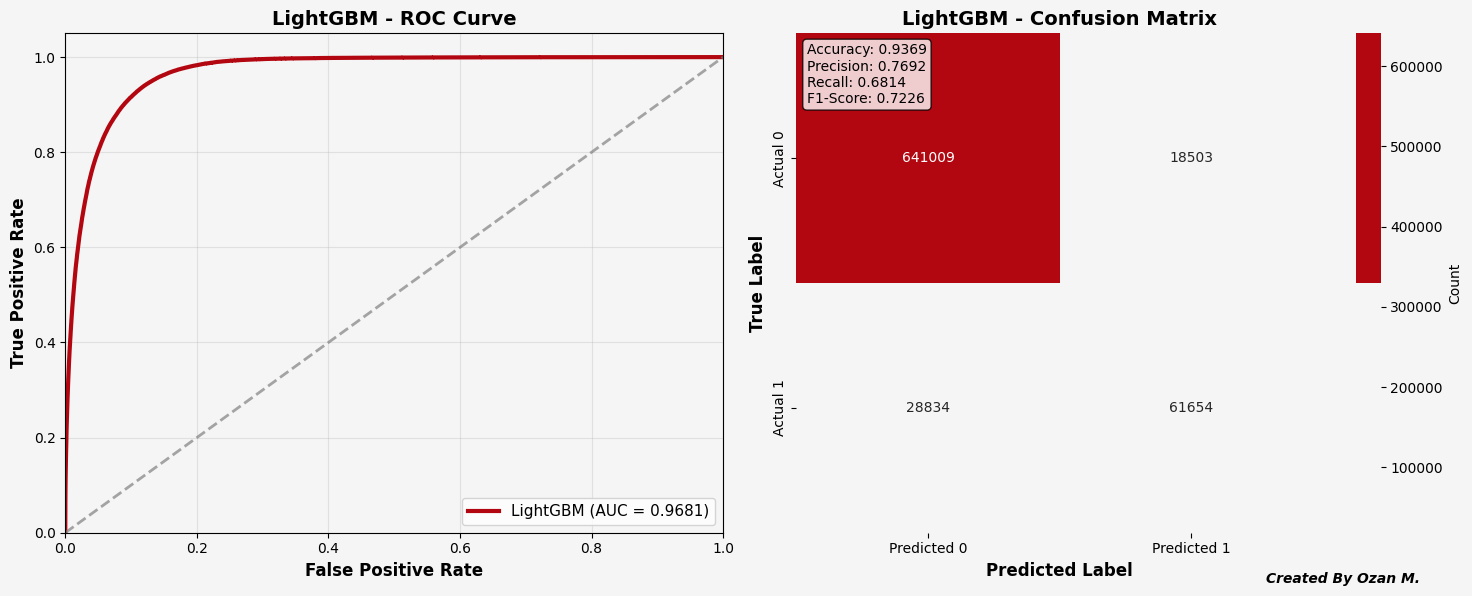


LightGBM Performance Metrics:
ROC AUC Score: 0.968106
Accuracy: 0.9369
Precision: 0.7692
Recall: 0.6814
F1-Score: 0.7226
--------------------------------------------------


In [12]:
from sklearn.metrics import roc_curve, auc, confusion_matrix

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.patch.set_facecolor('#f6f5f5')

print("="*50)
print("MODEL 1 EVALUATION: LightGBM")
print("="*50)

fpr, tpr, thresholds = roc_curve(y, lgb_oof)
roc_auc = auc(fpr, tpr)

ax1.plot(fpr, tpr, color='#b20710', lw=3, label=f'LightGBM (AUC = {roc_auc:.4f})')
ax1.plot([0, 1], [0, 1], color='grey', lw=2, linestyle='--', alpha=0.7)
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
ax1.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
ax1.set_title('LightGBM - ROC Curve', fontsize=14, fontweight='bold')
ax1.legend(loc="lower right", fontsize=11)
ax1.grid(alpha=0.3)
ax1.set_facecolor('#f6f5f5')

y_pred_binary = (lgb_oof >= 0.5).astype(int)
cm = confusion_matrix(y, y_pred_binary)

sns.heatmap(cm, annot=True, fmt='d', cmap=['#f6f5f5', '#b20710'], 
            cbar_kws={'label': 'Count'}, ax=ax2,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
ax2.set_title('LightGBM - Confusion Matrix', fontsize=14, fontweight='bold')
ax2.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
ax2.set_ylabel('True Label', fontsize=12, fontweight='bold')

tn, fp, fn, tp = cm.ravel()
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

metrics_text = f'Accuracy: {accuracy:.4f}\nPrecision: {precision:.4f}\nRecall: {recall:.4f}\nF1-Score: {f1:.4f}'
ax2.text(0.02, 0.98, metrics_text, transform=ax2.transAxes, fontsize=10,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

fig.text(0.95, 0.02, 'Created By Ozan M.', fontsize=10, 
         style='italic', alpha=1.0, ha='right', color='black', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nLightGBM Performance Metrics:")
print(f"ROC AUC Score: {roc_auc:.6f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print("-" * 50)

<h2 style="background-color:#000000; color:#39ff14; padding:10px; border-radius:6px; font-family:sans-serif; text-shadow: 0 0 5px #39ff14, 0 0 10px #39ff14, 0 0 20px #39ff14;">
🔥 XGBoost Model
</h2>

In [13]:
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold

print("="*50)
print("MODEL 2: XGBoost Classifier")
print("="*50)

xgb_params = {
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'booster': 'gbtree',
    'max_depth': 6,
    'learning_rate': 0.05,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'min_child_weight': 1,
    'reg_alpha': 0.1,
    'reg_lambda': 1,
    'random_state': 42,
    'n_estimators': 1000,
    'early_stopping_rounds': 100,
    'verbosity': 1
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []
oof_predictions = np.zeros(len(X_processed))
test_predictions = np.zeros(len(X_test_processed))

print("Training XGBoost with 5-fold cross-validation...")

for fold, (train_idx, val_idx) in enumerate(skf.split(X_processed, y)):
    print(f"\nFold {fold + 1}/5")
    
  
    X_fold_train, X_fold_val = X_processed.iloc[train_idx], X_processed.iloc[val_idx]
    y_fold_train, y_fold_val = y.iloc[train_idx], y.iloc[val_idx]
    
    model = xgb.XGBClassifier(**xgb_params)
    
    model.fit(
        X_fold_train, y_fold_train,
        eval_set=[(X_fold_train, y_fold_train), (X_fold_val, y_fold_val)],
        verbose=100
    )
  
    val_pred = model.predict_proba(X_fold_val)[:, 1]
    test_pred = model.predict_proba(X_test_processed)[:, 1]
    
    oof_predictions[val_idx] = val_pred
    test_predictions += test_pred / 5

    fold_score = roc_auc_score(y_fold_val, val_pred)
    cv_scores.append(fold_score)
    print(f"Fold {fold + 1} ROC AUC: {fold_score:.6f}")

overall_cv_score = roc_auc_score(y, oof_predictions)
print(f"\n" + "="*30)
print(f"XGBoost Results:")
print(f"CV Scores: {[f'{score:.6f}' for score in cv_scores]}")
print(f"Mean CV Score: {np.mean(cv_scores):.6f} ± {np.std(cv_scores):.6f}")
print(f"Overall OOF Score: {overall_cv_score:.6f}")
print(f"="*30)

xgb_oof = oof_predictions.copy()
xgb_test = test_predictions.copy()
xgb_score = overall_cv_score

print(f"\nXGBoost training completed!")
print(f"Best ROC AUC Score: {xgb_score:.6f}")

print(f"\nModel Comparison so far:")
print(f"LightGBM: {lgb_score:.6f}")
print(f"XGBoost:  {xgb_score:.6f}")
print(f"Difference: {abs(lgb_score - xgb_score):.6f}")

MODEL 2: XGBoost Classifier
Training XGBoost with 5-fold cross-validation...

Fold 1/5
[0]	validation_0-auc:0.93286	validation_1-auc:0.93208
[100]	validation_0-auc:0.96042	validation_1-auc:0.95972
[200]	validation_0-auc:0.96542	validation_1-auc:0.96427
[300]	validation_0-auc:0.96766	validation_1-auc:0.96578
[400]	validation_0-auc:0.96914	validation_1-auc:0.96659
[500]	validation_0-auc:0.97041	validation_1-auc:0.96722
[600]	validation_0-auc:0.97149	validation_1-auc:0.96767
[700]	validation_0-auc:0.97237	validation_1-auc:0.96795
[800]	validation_0-auc:0.97319	validation_1-auc:0.96818
[900]	validation_0-auc:0.97394	validation_1-auc:0.96832
[999]	validation_0-auc:0.97461	validation_1-auc:0.96849
Fold 1 ROC AUC: 0.968492

Fold 2/5
[0]	validation_0-auc:0.93165	validation_1-auc:0.93092
[100]	validation_0-auc:0.96088	validation_1-auc:0.95912
[200]	validation_0-auc:0.96550	validation_1-auc:0.96280
[300]	validation_0-auc:0.96781	validation_1-auc:0.96439
[400]	validation_0-auc:0.96947	validation_

<h2 style="background-color:#000000; color:#39ff14; padding:10px; border-radius:6px; font-family:sans-serif; text-shadow: 0 0 5px #39ff14, 0 0 10px #39ff14, 0 0 20px #39ff14;">
📉 ROC-AUC Curve & Confusion Matrix
</h2>

MODEL 2 EVALUATION: XGBoost


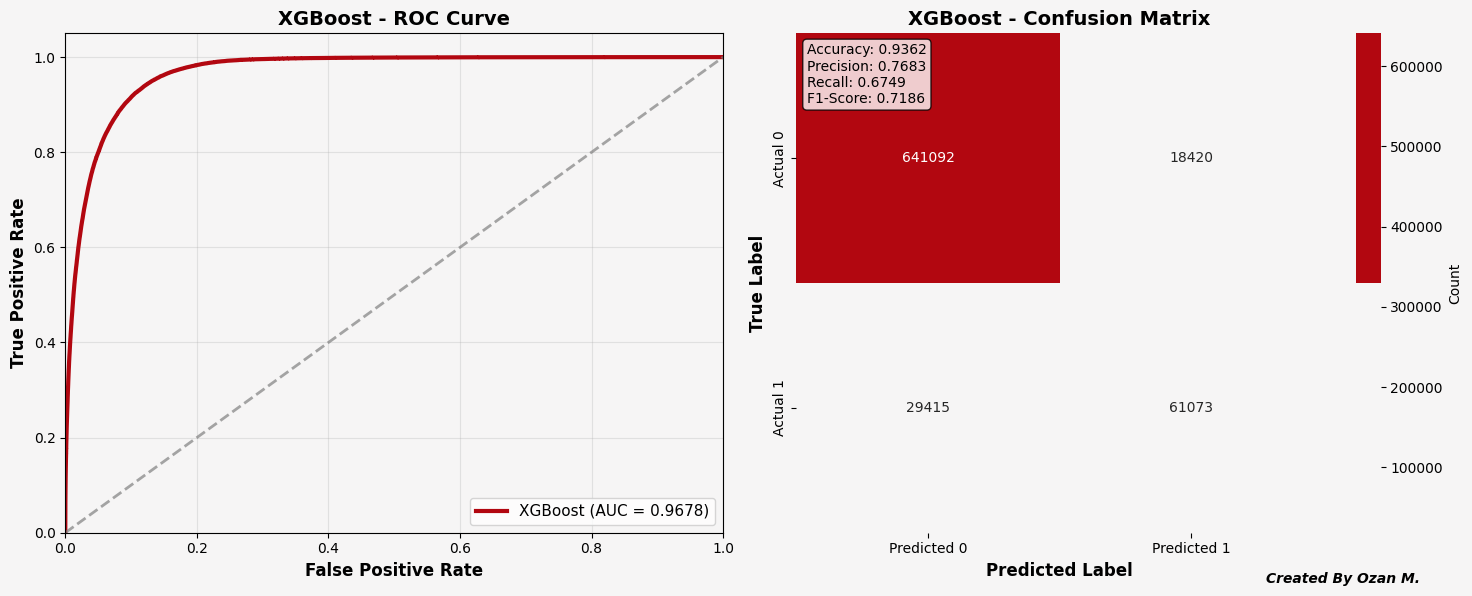


XGBoost Performance Metrics:
ROC AUC Score: 0.967822
Accuracy: 0.9362
Precision: 0.7683
Recall: 0.6749
F1-Score: 0.7186
--------------------------------------------------


In [14]:
from sklearn.metrics import roc_curve, auc, confusion_matrix

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.patch.set_facecolor('#f6f5f5')

print("="*50)
print("MODEL 2 EVALUATION: XGBoost")
print("="*50)

fpr, tpr, thresholds = roc_curve(y, xgb_oof)
roc_auc = auc(fpr, tpr)

ax1.plot(fpr, tpr, color='#b20710', lw=3, label=f'XGBoost (AUC = {roc_auc:.4f})')
ax1.plot([0, 1], [0, 1], color='grey', lw=2, linestyle='--', alpha=0.7)
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
ax1.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
ax1.set_title('XGBoost - ROC Curve', fontsize=14, fontweight='bold')
ax1.legend(loc="lower right", fontsize=11)
ax1.grid(alpha=0.3)
ax1.set_facecolor('#f6f5f5')

y_pred_binary = (xgb_oof >= 0.5).astype(int)
cm = confusion_matrix(y, y_pred_binary)

sns.heatmap(cm, annot=True, fmt='d', cmap=['#f6f5f5', '#b20710'], 
            cbar_kws={'label': 'Count'}, ax=ax2,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
ax2.set_title('XGBoost - Confusion Matrix', fontsize=14, fontweight='bold')
ax2.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
ax2.set_ylabel('True Label', fontsize=12, fontweight='bold')

tn, fp, fn, tp = cm.ravel()
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

metrics_text = f'Accuracy: {accuracy:.4f}\nPrecision: {precision:.4f}\nRecall: {recall:.4f}\nF1-Score: {f1:.4f}'
ax2.text(0.02, 0.98, metrics_text, transform=ax2.transAxes, fontsize=10,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

fig.text(0.95, 0.02, 'Created By Ozan M.', fontsize=10, 
         style='italic', alpha=1.0, ha='right', color='black', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nXGBoost Performance Metrics:")
print(f"ROC AUC Score: {roc_auc:.6f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print("-" * 50)

<h2 style="background-color:#000000; color:#39ff14; padding:10px; border-radius:6px; font-family:sans-serif; text-shadow: 0 0 5px #39ff14, 0 0 10px #39ff14, 0 0 20px #39ff14;">
🐱 CatBoost Model
</h2>

In [15]:
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold

print("="*50)
print("MODEL 3: CatBoost Classifier")
print("="*50)

cat_params = {
    'objective': 'Logloss',
    'eval_metric': 'AUC',
    'iterations': 1000,
    'learning_rate': 0.05,
    'depth': 6,
    'l2_leaf_reg': 3,
    'subsample': 0.8,
    'colsample_bylevel': 0.8,
    'random_seed': 42,
    'early_stopping_rounds': 100,
    'verbose': 100,
    'use_best_model': True,
    'thread_count': -1
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []
oof_predictions = np.zeros(len(X_processed))
test_predictions = np.zeros(len(X_test_processed))

print("Training CatBoost with 5-fold cross-validation...")

for fold, (train_idx, val_idx) in enumerate(skf.split(X_processed, y)):
    print(f"\nFold {fold + 1}/5")

    X_fold_train, X_fold_val = X_processed.iloc[train_idx], X_processed.iloc[val_idx]
    y_fold_train, y_fold_val = y.iloc[train_idx], y.iloc[val_idx]
    
    model = CatBoostClassifier(**cat_params)
    
    model.fit(
        X_fold_train, y_fold_train,
        eval_set=(X_fold_val, y_fold_val),
        plot=False
    )
    
    val_pred = model.predict_proba(X_fold_val)[:, 1]
    test_pred = model.predict_proba(X_test_processed)[:, 1]

    oof_predictions[val_idx] = val_pred
    test_predictions += test_pred / 5
    
    fold_score = roc_auc_score(y_fold_val, val_pred)
    cv_scores.append(fold_score)
    print(f"Fold {fold + 1} ROC AUC: {fold_score:.6f}")

overall_cv_score = roc_auc_score(y, oof_predictions)
print(f"\n" + "="*30)
print(f"CatBoost Results:")
print(f"CV Scores: {[f'{score:.6f}' for score in cv_scores]}")
print(f"Mean CV Score: {np.mean(cv_scores):.6f} ± {np.std(cv_scores):.6f}")
print(f"Overall OOF Score: {overall_cv_score:.6f}")
print(f"="*30)

cat_oof = oof_predictions.copy()
cat_test = test_predictions.copy()
cat_score = overall_cv_score

print(f"\nCatBoost training completed!")
print(f"Best ROC AUC Score: {cat_score:.6f}")

print(f"\nModel Comparison so far:")
print(f"LightGBM: {lgb_score:.6f}")
print(f"XGBoost:  {xgb_score:.6f}")
print(f"CatBoost: {cat_score:.6f}")

models_scores = [
    ('LightGBM', lgb_score),
    ('XGBoost', xgb_score),
    ('CatBoost', cat_score)
]
models_scores.sort(key=lambda x: x[1], reverse=True)
print(f"\nCurrent Rankings:")
for i, (name, score) in enumerate(models_scores, 1):
    print(f"{i}. {name}: {score:.6f}")

MODEL 3: CatBoost Classifier
Training CatBoost with 5-fold cross-validation...

Fold 1/5
0:	test: 0.9197686	best: 0.9197686 (0)	total: 153ms	remaining: 2m 32s
100:	test: 0.9539329	best: 0.9539329 (100)	total: 8.82s	remaining: 1m 18s
200:	test: 0.9589066	best: 0.9589066 (200)	total: 17.4s	remaining: 1m 9s
300:	test: 0.9615571	best: 0.9615571 (300)	total: 26.8s	remaining: 1m 2s
400:	test: 0.9627785	best: 0.9627785 (400)	total: 35.4s	remaining: 52.8s
500:	test: 0.9636352	best: 0.9636352 (500)	total: 44s	remaining: 43.8s
600:	test: 0.9643501	best: 0.9643501 (600)	total: 53.5s	remaining: 35.5s
700:	test: 0.9648719	best: 0.9648719 (700)	total: 1m 2s	remaining: 26.5s
800:	test: 0.9652623	best: 0.9652623 (800)	total: 1m 10s	remaining: 17.6s
900:	test: 0.9655611	best: 0.9655611 (900)	total: 1m 19s	remaining: 8.72s
999:	test: 0.9658601	best: 0.9658601 (999)	total: 1m 28s	remaining: 0us

bestTest = 0.9658601164
bestIteration = 999

Fold 1 ROC AUC: 0.965860

Fold 2/5
0:	test: 0.9206690	best: 0.920

<h2 style="background-color:#000000; color:#39ff14; padding:10px; border-radius:6px; font-family:sans-serif; text-shadow: 0 0 5px #39ff14, 0 0 10px #39ff14, 0 0 20px #39ff14;">
📉 ROC-AUC Curve & Confusion Matrix
</h2>

MODEL 3 EVALUATION: CatBoost


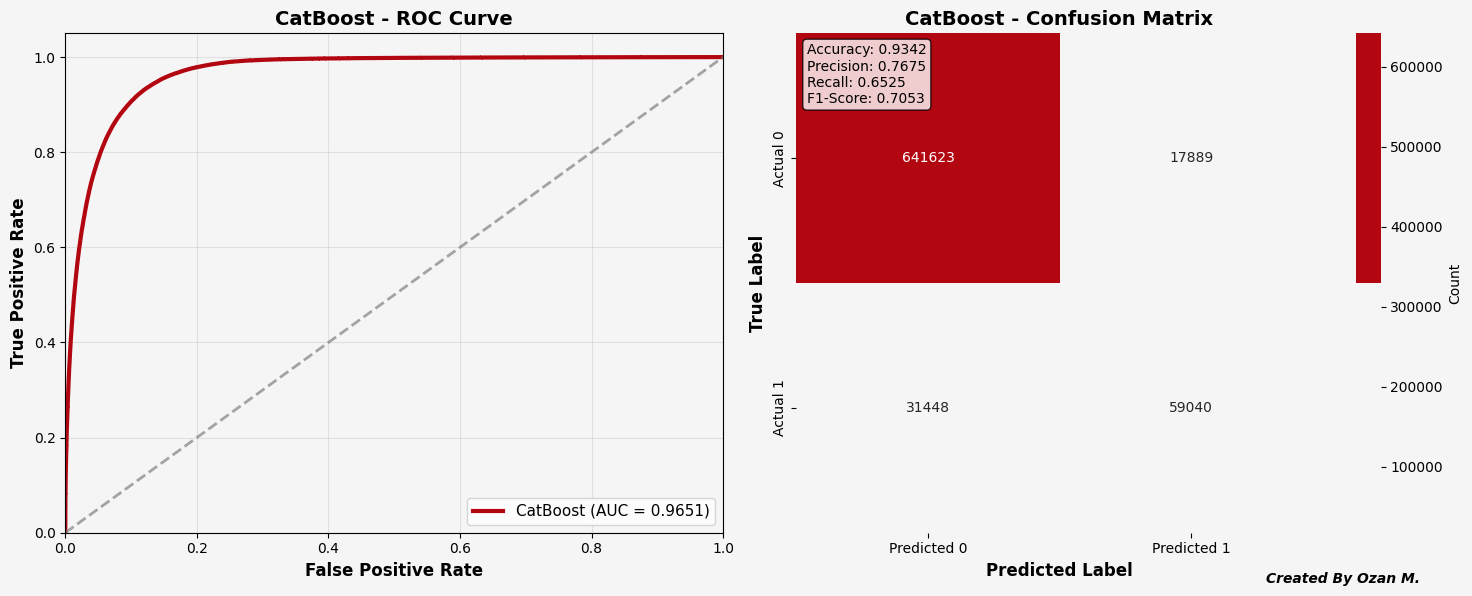


CatBoost Performance Metrics:
ROC AUC Score: 0.965136
Accuracy: 0.9342
Precision: 0.7675
Recall: 0.6525
F1-Score: 0.7053
--------------------------------------------------


In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.patch.set_facecolor('#f6f5f5')

print("="*50)
print("MODEL 3 EVALUATION: CatBoost")
print("="*50)

# ROC Curve
fpr, tpr, thresholds = roc_curve(y, cat_oof)
roc_auc = auc(fpr, tpr)

ax1.plot(fpr, tpr, color='#b20710', lw=3, label=f'CatBoost (AUC = {roc_auc:.4f})')
ax1.plot([0, 1], [0, 1], color='grey', lw=2, linestyle='--', alpha=0.7)
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
ax1.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
ax1.set_title('CatBoost - ROC Curve', fontsize=14, fontweight='bold')
ax1.legend(loc="lower right", fontsize=11)
ax1.grid(alpha=0.3)
ax1.set_facecolor('#f6f5f5')

y_pred_binary = (cat_oof >= 0.5).astype(int)
cm = confusion_matrix(y, y_pred_binary)

sns.heatmap(cm, annot=True, fmt='d', cmap=['#f6f5f5', '#b20710'], 
            cbar_kws={'label': 'Count'}, ax=ax2,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
ax2.set_title('CatBoost - Confusion Matrix', fontsize=14, fontweight='bold')
ax2.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
ax2.set_ylabel('True Label', fontsize=12, fontweight='bold')

tn, fp, fn, tp = cm.ravel()
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

metrics_text = f'Accuracy: {accuracy:.4f}\nPrecision: {precision:.4f}\nRecall: {recall:.4f}\nF1-Score: {f1:.4f}'
ax2.text(0.02, 0.98, metrics_text, transform=ax2.transAxes, fontsize=10,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

fig.text(0.95, 0.02, 'Created By Ozan M.', fontsize=10, 
         style='italic', alpha=1.0, ha='right', color='black', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nCatBoost Performance Metrics:")
print(f"ROC AUC Score: {roc_auc:.6f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print("-" * 50)

<h2 style="background-color:#000000; color:#39ff14; padding:10px; border-radius:6px; font-family:sans-serif; text-shadow: 0 0 5px #39ff14, 0 0 10px #39ff14, 0 0 20px #39ff14;">
🌲 Random Forest Model
</h2>

In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold

import warnings
from sklearn.utils._testing import ignore_warnings
warnings.filterwarnings('ignore')

print("="*50)
print("MODEL 4: Random Forest Classifier")
print("="*50)

# Random Forest parameters
rf_params = {
    'n_estimators': 500,
    'max_depth': 15,
    'min_samples_split': 10,
    'min_samples_leaf': 4,
    'max_features': 'sqrt',
    'bootstrap': True,
    'random_state': 42,
    'n_jobs': -1,
    'verbose': 1
}

# Cross-validation setup
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []
oof_predictions = np.zeros(len(X_processed))
test_predictions = np.zeros(len(X_test_processed))

print("Training Random Forest with 5-fold cross-validation...")

for fold, (train_idx, val_idx) in enumerate(skf.split(X_processed, y)):
    print(f"\nFold {fold + 1}/5")
    
    # Split data
    X_fold_train, X_fold_val = X_processed.iloc[train_idx], X_processed.iloc[val_idx]
    y_fold_train, y_fold_val = y.iloc[train_idx], y.iloc[val_idx]
    
    # Create Random Forest model
    model = RandomForestClassifier(**rf_params)
    
    # Train model
    print("Training Random Forest...")
    model.fit(X_fold_train, y_fold_train)
    
    # Predictions
    val_pred = model.predict_proba(X_fold_val)[:, 1]
    test_pred = model.predict_proba(X_test_processed)[:, 1]
    
    # Store predictions
    oof_predictions[val_idx] = val_pred
    test_predictions += test_pred / 5
    
    # Calculate fold score
    fold_score = roc_auc_score(y_fold_val, val_pred)
    cv_scores.append(fold_score)
    print(f"Fold {fold + 1} ROC AUC: {fold_score:.6f}")

# Overall CV score
overall_cv_score = roc_auc_score(y, oof_predictions)
print(f"\n" + "="*30)
print(f"Random Forest Results:")
print(f"CV Scores: {[f'{score:.6f}' for score in cv_scores]}")
print(f"Mean CV Score: {np.mean(cv_scores):.6f} ± {np.std(cv_scores):.6f}")
print(f"Overall OOF Score: {overall_cv_score:.6f}")
print(f"="*30)

# Store results
rf_oof = oof_predictions.copy()
rf_test = test_predictions.copy()
rf_score = overall_cv_score

print(f"\nRandom Forest training completed!")
print(f"Best ROC AUC Score: {rf_score:.6f}")

# Compare with previous models
print(f"\nModel Comparison so far:")
print(f"LightGBM:      {lgb_score:.6f}")
print(f"XGBoost:       {xgb_score:.6f}")
print(f"CatBoost:      {cat_score:.6f}")
print(f"Random Forest: {rf_score:.6f}")

# Rank models
models_scores = [
    ('LightGBM', lgb_score),
    ('XGBoost', xgb_score),
    ('CatBoost', cat_score),
    ('Random Forest', rf_score)
]
models_scores.sort(key=lambda x: x[1], reverse=True)
print(f"\nCurrent Rankings:")
for i, (name, score) in enumerate(models_scores, 1):
    print(f"{i}. {name}: {score:.6f}")

MODEL 4: Random Forest Classifier
Training Random Forest with 5-fold cross-validation...

Fold 1/5
Training Random Forest...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:   21.6s
[Parallel(n_jobs=-1)]: Done 192 tasks      | elapsed:  1.6min
[Parallel(n_jobs=-1)]: Done 442 tasks      | elapsed:  3.7min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:  4.2min finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.5s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:    2.4s
[Parallel(n_jobs=4)]: Done 442 tasks      | elapsed:    4.9s
[Parallel(n_jobs=4)]: Done 500 out of 500 | elapsed:    5.4s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.7s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:    3.1s
[Parallel(n_jobs=4)]: Done 442 tasks      | elapsed:    6.9s
[Parallel(n_jobs=4)]: Done 500 out of 500 | elapsed:    7.9s finis

Fold 1 ROC AUC: 0.960857

Fold 2/5
Training Random Forest...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:   21.5s
[Parallel(n_jobs=-1)]: Done 192 tasks      | elapsed:  1.6min
[Parallel(n_jobs=-1)]: Done 442 tasks      | elapsed:  3.6min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:  4.0min finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.4s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:    1.9s
[Parallel(n_jobs=4)]: Done 442 tasks      | elapsed:    4.2s
[Parallel(n_jobs=4)]: Done 500 out of 500 | elapsed:    4.8s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.7s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:    3.6s
[Parallel(n_jobs=4)]: Done 442 tasks      | elapsed:    7.6s
[Parallel(n_jobs=4)]: Done 500 out of 500 | elapsed:    8.5s finis

Fold 2 ROC AUC: 0.960184

Fold 3/5
Training Random Forest...


...

Fold 3 ROC AUC: 0.959940

Fold 4/5
Training Random Forest...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:   20.8s
[Parallel(n_jobs=-1)]: Done 192 tasks      | elapsed:  1.5min
[Parallel(n_jobs=-1)]: Done 442 tasks      | elapsed:  3.6min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:  4.0min finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.4s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:    1.8s
[Parallel(n_jobs=4)]: Done 442 tasks      | elapsed:    4.2s
[Parallel(n_jobs=4)]: Done 500 out of 500 | elapsed:    4.8s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.7s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:    3.1s
[Parallel(n_jobs=4)]: Done 442 tasks      | elapsed:    7.1s
[Parallel(n_jobs=4)]: Done 500 out of 500 | elapsed:    8.3s finis

Fold 4 ROC AUC: 0.961196

Fold 5/5
Training Random Forest...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:   20.8s
[Parallel(n_jobs=-1)]: Done 192 tasks      | elapsed:  1.5min
[Parallel(n_jobs=-1)]: Done 442 tasks      | elapsed:  3.5min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:  4.0min finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.4s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:    1.8s
[Parallel(n_jobs=4)]: Done 442 tasks      | elapsed:    4.2s
[Parallel(n_jobs=4)]: Done 500 out of 500 | elapsed:    4.8s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.7s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:    3.1s
[Parallel(n_jobs=4)]: Done 442 tasks      | elapsed:    7.1s
[Parallel(n_jobs=4)]: Done 500 out of 500 | elapsed:    8.0s finis

Fold 5 ROC AUC: 0.960798

Random Forest Results:
CV Scores: ['0.960857', '0.960184', '0.959940', '0.961196', '0.960798']
Mean CV Score: 0.960595 ± 0.000462
Overall OOF Score: 0.960592

Random Forest training completed!
Best ROC AUC Score: 0.960592

Model Comparison so far:
LightGBM:      0.968106
XGBoost:       0.967822
CatBoost:      0.965136
Random Forest: 0.960592

Current Rankings:
1. LightGBM: 0.968106
2. XGBoost: 0.967822
3. CatBoost: 0.965136
4. Random Forest: 0.960592


<h2 style="background-color:#000000; color:#39ff14; padding:10px; border-radius:6px; font-family:sans-serif; text-shadow: 0 0 5px #39ff14, 0 0 10px #39ff14, 0 0 20px #39ff14;">
📉 ROC-AUC Curve & Confusion Matrix
</h2>

MODEL 4 EVALUATION: Random Forest


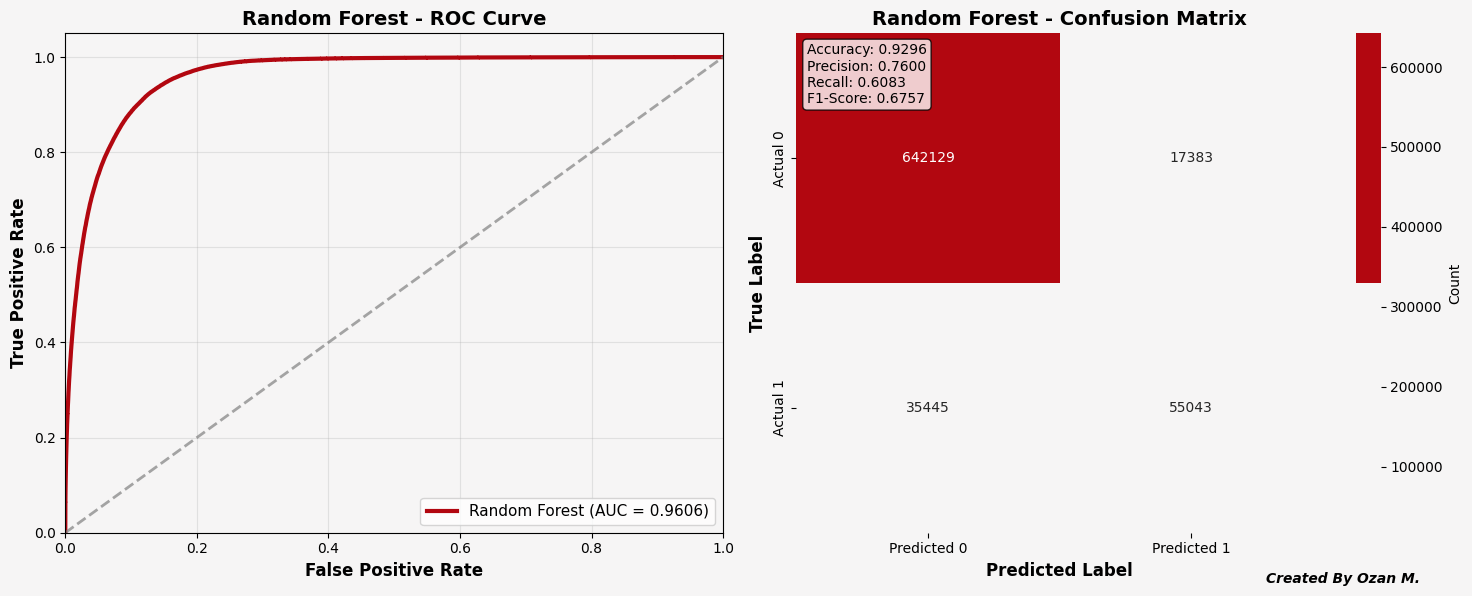


Random Forest Performance Metrics:
ROC AUC Score: 0.960592
Accuracy: 0.9296
Precision: 0.7600
Recall: 0.6083
F1-Score: 0.6757
--------------------------------------------------


In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.patch.set_facecolor('#f6f5f5')

print("="*50)
print("MODEL 4 EVALUATION: Random Forest")
print("="*50)

fpr, tpr, thresholds = roc_curve(y, rf_oof)
roc_auc = auc(fpr, tpr)

ax1.plot(fpr, tpr, color='#b20710', lw=3, label=f'Random Forest (AUC = {roc_auc:.4f})')
ax1.plot([0, 1], [0, 1], color='grey', lw=2, linestyle='--', alpha=0.7)
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
ax1.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
ax1.set_title('Random Forest - ROC Curve', fontsize=14, fontweight='bold')
ax1.legend(loc="lower right", fontsize=11)
ax1.grid(alpha=0.3)
ax1.set_facecolor('#f6f5f5')

y_pred_binary = (rf_oof >= 0.5).astype(int)
cm = confusion_matrix(y, y_pred_binary)

sns.heatmap(cm, annot=True, fmt='d', cmap=['#f6f5f5', '#b20710'], 
            cbar_kws={'label': 'Count'}, ax=ax2,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
ax2.set_title('Random Forest - Confusion Matrix', fontsize=14, fontweight='bold')
ax2.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
ax2.set_ylabel('True Label', fontsize=12, fontweight='bold')

tn, fp, fn, tp = cm.ravel()
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

metrics_text = f'Accuracy: {accuracy:.4f}\nPrecision: {precision:.4f}\nRecall: {recall:.4f}\nF1-Score: {f1:.4f}'
ax2.text(0.02, 0.98, metrics_text, transform=ax2.transAxes, fontsize=10,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

fig.text(0.95, 0.02, 'Created By Ozan M.', fontsize=10, 
         style='italic', alpha=1.0, ha='right', color='black', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nRandom Forest Performance Metrics:")
print(f"ROC AUC Score: {roc_auc:.6f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print("-" * 50)

<h2 style="background-color:#000000; color:#39ff14; padding:10px; border-radius:6px; font-family:sans-serif; text-shadow: 0 0 5px #39ff14, 0 0 10px #39ff14, 0 0 20px #39ff14;">
🌳 Extra Trees Model
</h2>

In [19]:
from sklearn.ensemble import ExtraTreesClassifier

print("="*50)
print("MODEL 5: Extra Trees Classifier")
print("="*50)

et_params = {
    'n_estimators': 500,
    'max_depth': 15,
    'min_samples_split': 10,
    'min_samples_leaf': 4,
    'max_features': 'sqrt',
    'bootstrap': False,  # Extra Trees doesn't use bootstrap
    'random_state': 42,
    'n_jobs': -1,
    'verbose': 0  # Set to 0 to reduce output
}

# Cross-validation setup
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []
oof_predictions = np.zeros(len(X_processed))
test_predictions = np.zeros(len(X_test_processed))

print("Training Extra Trees with 5-fold cross-validation...")

for fold, (train_idx, val_idx) in enumerate(skf.split(X_processed, y)):
    print(f"\nFold {fold + 1}/5")
    
    # Split data
    X_fold_train, X_fold_val = X_processed.iloc[train_idx], X_processed.iloc[val_idx]
    y_fold_train, y_fold_val = y.iloc[train_idx], y.iloc[val_idx]
    
    # Create Extra Trees model
    model = ExtraTreesClassifier(**et_params)
    
    # Train model
    print("Training Extra Trees...")
    model.fit(X_fold_train, y_fold_train)
    
    # Predictions
    val_pred = model.predict_proba(X_fold_val)[:, 1]
    test_pred = model.predict_proba(X_test_processed)[:, 1]
    
    # Store predictions
    oof_predictions[val_idx] = val_pred
    test_predictions += test_pred / 5
    
    # Calculate fold score
    fold_score = roc_auc_score(y_fold_val, val_pred)
    cv_scores.append(fold_score)
    print(f"Fold {fold + 1} ROC AUC: {fold_score:.6f}")

# Overall CV score
overall_cv_score = roc_auc_score(y, oof_predictions)
print(f"\n" + "="*30)
print(f"Extra Trees Results:")
print(f"CV Scores: {[f'{score:.6f}' for score in cv_scores]}")
print(f"Mean CV Score: {np.mean(cv_scores):.6f} ± {np.std(cv_scores):.6f}")
print(f"Overall OOF Score: {overall_cv_score:.6f}")
print(f"="*30)

# Store results
et_oof = oof_predictions.copy()
et_test = test_predictions.copy()
et_score = overall_cv_score

print(f"\nExtra Trees training completed!")
print(f"Best ROC AUC Score: {et_score:.6f}")

# Final model comparison
print(f"\n" + "="*60)
print("FINAL MODEL COMPARISON - ALL 5 MODELS")
print("="*60)
print(f"1. LightGBM:      {lgb_score:.6f}")
print(f"2. XGBoost:       {xgb_score:.6f}")
print(f"3. CatBoost:      {cat_score:.6f}")
print(f"4. Random Forest: {rf_score:.6f}")
print(f"5. Extra Trees:   {et_score:.6f}")

# Rank all models
all_models = [
    ('LightGBM', lgb_score, lgb_oof, lgb_test),
    ('XGBoost', xgb_score, xgb_oof, xgb_test),
    ('CatBoost', cat_score, cat_oof, cat_test),
    ('Random Forest', rf_score, rf_oof, rf_test),
    ('Extra Trees', et_score, et_oof, et_test)
]
all_models.sort(key=lambda x: x[1], reverse=True)

print(f"\nFINAL RANKINGS:")
for i, (name, score, _, _) in enumerate(all_models, 1):
    print(f"{i}. {name}: {score:.6f}")

# Select top 3 for stacking
top_3_models = all_models[:3]
print(f"\nTOP 3 MODELS SELECTED FOR STACKING:")
for i, (name, score, _, _) in enumerate(top_3_models, 1):
    print(f"{i}. {name}: {score:.6f}")

print(f"\nReady for stacking ensemble!")
print("="*60)

MODEL 5: Extra Trees Classifier
Training Extra Trees with 5-fold cross-validation...

Fold 1/5
Training Extra Trees...
Fold 1 ROC AUC: 0.948971

Fold 2/5
Training Extra Trees...
Fold 2 ROC AUC: 0.948268

Fold 3/5
Training Extra Trees...
Fold 3 ROC AUC: 0.948094

Fold 4/5
Training Extra Trees...
Fold 4 ROC AUC: 0.949057

Fold 5/5
Training Extra Trees...
Fold 5 ROC AUC: 0.948741

Extra Trees Results:
CV Scores: ['0.948971', '0.948268', '0.948094', '0.949057', '0.948741']
Mean CV Score: 0.948626 ± 0.000382
Overall OOF Score: 0.948626

Extra Trees training completed!
Best ROC AUC Score: 0.948626

FINAL MODEL COMPARISON - ALL 5 MODELS
1. LightGBM:      0.968106
2. XGBoost:       0.967822
3. CatBoost:      0.965136
4. Random Forest: 0.960592
5. Extra Trees:   0.948626

FINAL RANKINGS:
1. LightGBM: 0.968106
2. XGBoost: 0.967822
3. CatBoost: 0.965136
4. Random Forest: 0.960592
5. Extra Trees: 0.948626

TOP 3 MODELS SELECTED FOR STACKING:
1. LightGBM: 0.968106
2. XGBoost: 0.967822
3. CatBoost: 

<h2 style="background-color:#000000; color:#39ff14; padding:10px; border-radius:6px; font-family:sans-serif; text-shadow: 0 0 5px #39ff14, 0 0 10px #39ff14, 0 0 20px #39ff14;">
📉 ROC-AUC Curve & Confusion Matrix
</h2>

MODEL 5 EVALUATION: Extra Trees


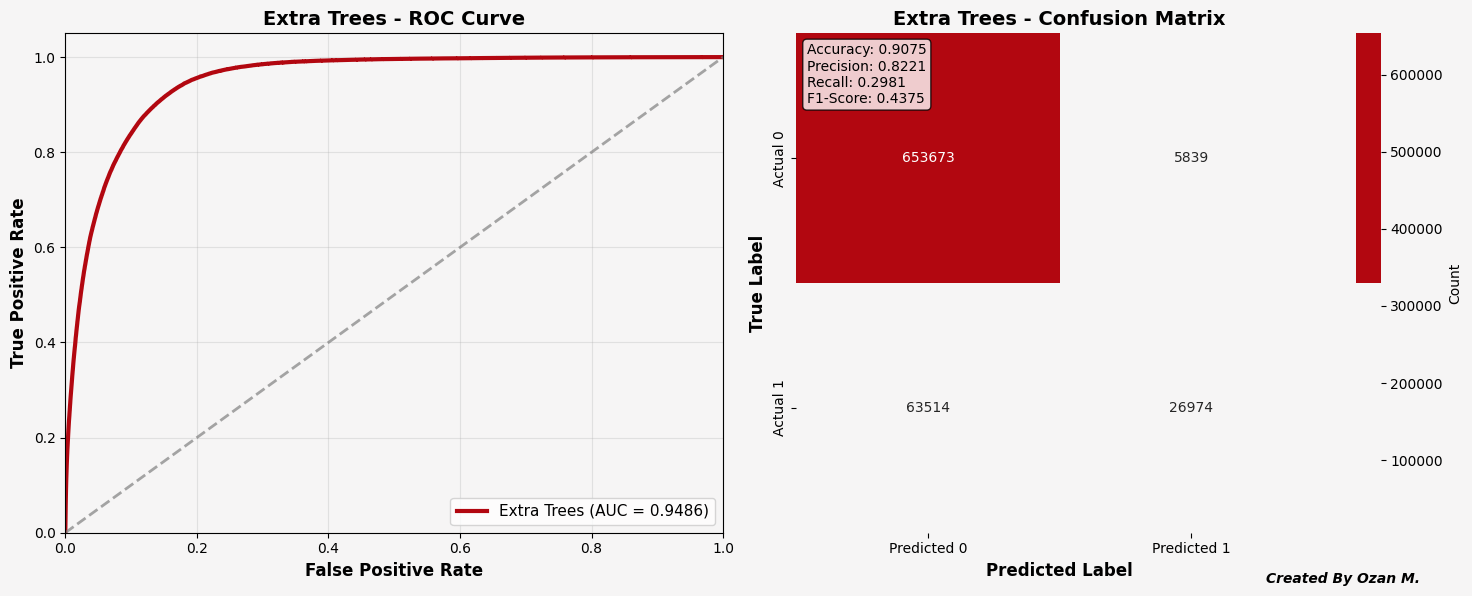


Extra Trees Performance Metrics:
ROC AUC Score: 0.948626
Accuracy: 0.9075
Precision: 0.8221
Recall: 0.2981
F1-Score: 0.4375
--------------------------------------------------

ALL MODELS EVALUATION COMPLETED!
Ready for stacking ensemble with top 3 models...


In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.patch.set_facecolor('#f6f5f5')

print("="*50)
print("MODEL 5 EVALUATION: Extra Trees")
print("="*50)

fpr, tpr, thresholds = roc_curve(y, et_oof)
roc_auc = auc(fpr, tpr)

ax1.plot(fpr, tpr, color='#b20710', lw=3, label=f'Extra Trees (AUC = {roc_auc:.4f})')
ax1.plot([0, 1], [0, 1], color='grey', lw=2, linestyle='--', alpha=0.7)
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
ax1.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
ax1.set_title('Extra Trees - ROC Curve', fontsize=14, fontweight='bold')
ax1.legend(loc="lower right", fontsize=11)
ax1.grid(alpha=0.3)
ax1.set_facecolor('#f6f5f5')

y_pred_binary = (et_oof >= 0.5).astype(int)
cm = confusion_matrix(y, y_pred_binary)

sns.heatmap(cm, annot=True, fmt='d', cmap=['#f6f5f5', '#b20710'], 
            cbar_kws={'label': 'Count'}, ax=ax2,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
ax2.set_title('Extra Trees - Confusion Matrix', fontsize=14, fontweight='bold')
ax2.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
ax2.set_ylabel('True Label', fontsize=12, fontweight='bold')

tn, fp, fn, tp = cm.ravel()
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

metrics_text = f'Accuracy: {accuracy:.4f}\nPrecision: {precision:.4f}\nRecall: {recall:.4f}\nF1-Score: {f1:.4f}'
ax2.text(0.02, 0.98, metrics_text, transform=ax2.transAxes, fontsize=10,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

fig.text(0.95, 0.02, 'Created By Ozan M.', fontsize=10, 
         style='italic', alpha=1.0, ha='right', color='black', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nExtra Trees Performance Metrics:")
print(f"ROC AUC Score: {roc_auc:.6f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print("-" * 50)

print("\n" + "="*60)
print("ALL MODELS EVALUATION COMPLETED!")
print("="*60)
print("Ready for stacking ensemble with top 3 models...")
print("="*60)

<h2 style="background-color:#000000; color:#39ff14; padding:10px; border-radius:6px; font-family:sans-serif; text-shadow: 0 0 5px #39ff14, 0 0 10px #39ff14, 0 0 20px #39ff14;">
🏁 5 Model Performance Comparison
</h2>

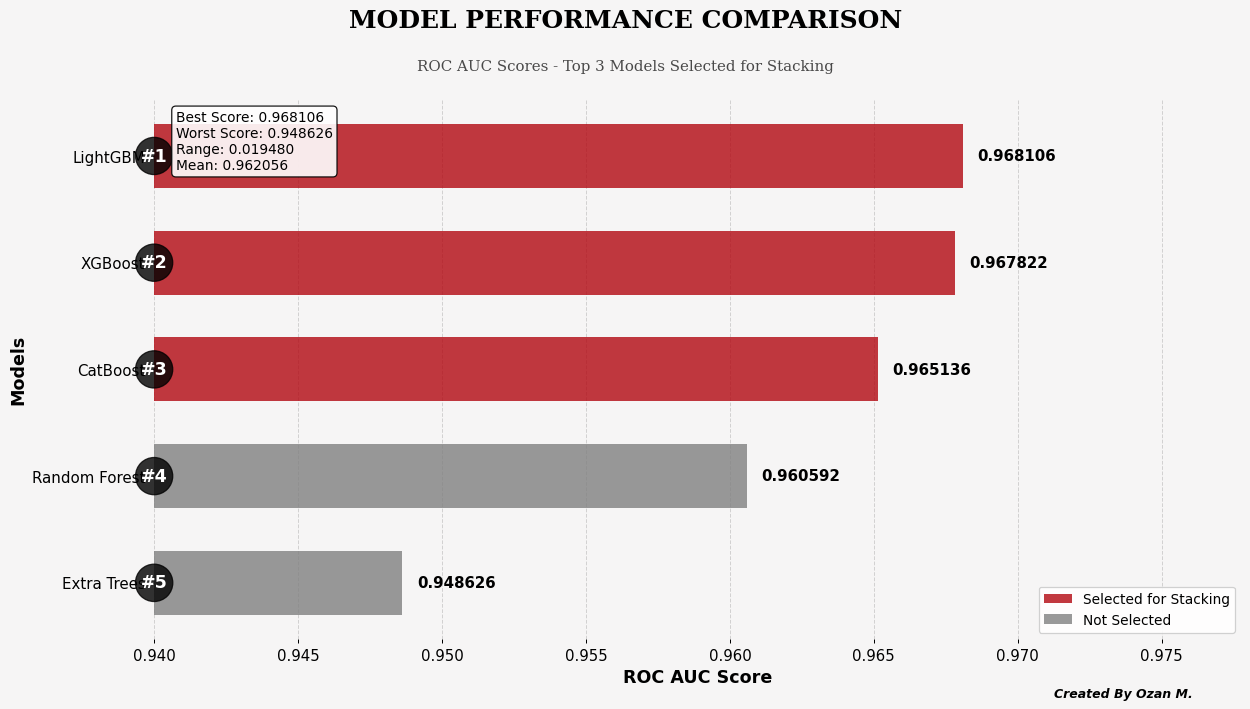

# MODEL COMPARISON SUMMARY
# ==================================================
# Top Performer:    LightGBM (0.968106)
# Second Best:      XGBoost (0.967822)
# Third Best:       CatBoost (0.965136)
# Performance Gap:  0.002970
# Selected Models:  LightGBM, XGBoost, CatBoost
# ==================================================


In [21]:
fig = plt.figure(figsize=(14, 8), dpi=90)
fig.patch.set_facecolor('#f6f5f5')

ax = plt.subplot()
ax.set_facecolor('#f6f5f5')

models = ['LightGBM', 'XGBoost', 'CatBoost', 'Random Forest', 'Extra Trees']
scores = [0.968106, 0.967822, 0.965136, 0.960592, 0.948626]

colors = ['#b20710', '#b20710', '#b20710', 'grey', 'grey']

bars = ax.barh(models, scores, color=colors, alpha=0.8, height=0.6)

ax.set_xlabel('ROC AUC Score', fontsize=14, fontweight='bold', color='black')
ax.set_ylabel('Models', fontsize=14, fontweight='bold', color='black')

for i, (bar, score) in enumerate(zip(bars, scores)):
    ax.text(score + 0.0005, bar.get_y() + bar.get_height()/2, 
            f'{score:.6f}', ha='left', va='center', fontweight='bold', 
            fontsize=12, color='black')

for i, (bar, rank) in enumerate(zip(bars, range(1, 6))):
    ax.text(0.94, bar.get_y() + bar.get_height()/2, 
            f'#{rank}', ha='center', va='center', fontweight='bold', 
            fontsize=14, color='white', 
            bbox=dict(boxstyle='circle', facecolor='black', alpha=0.8))

ax.grid(axis='x', alpha=0.3, linestyle='--', color='gray')
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_xlim(0.94, max(scores) * 1.01)

ax.tick_params(axis='both', labelsize=12, colors='black')

ax.invert_yaxis()

fig.text(0.5, 0.95, 'MODEL PERFORMANCE COMPARISON',
         {'font':'serif', 'size':20, 'weight':'bold','color':'black'}, ha='center')

fig.text(0.5, 0.89, 'ROC AUC Scores - Top 3 Models Selected for Stacking',
         {'font':'serif', 'size':12,'color':'black'}, alpha=0.7, ha='center')


legend_elements = [
    plt.Rectangle((0,0),1,1, facecolor='#b20710', alpha=0.8, label='Selected for Stacking'),
    plt.Rectangle((0,0),1,1, facecolor='grey', alpha=0.8, label='Not Selected')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=11, framealpha=0.9)


best_score = max(scores)
worst_score = min(scores)
score_range = best_score - worst_score
mean_score = np.mean(scores)

metrics_text = f'Best Score: {best_score:.6f}\nWorst Score: {worst_score:.6f}\nRange: {score_range:.6f}\nMean: {mean_score:.6f}'
ax.text(0.02, 0.98, metrics_text, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

fig.text(0.95, 0.02, 'Created By Ozan M.', fontsize=10, 
         style='italic', alpha=1.0, ha='right', color='black', fontweight='bold')

plt.tight_layout()
plt.subplots_adjust(bottom=0.1, top=0.85)
plt.show()

print("# MODEL COMPARISON SUMMARY")
print("# " + "="*50)
print(f"# Top Performer:    {models[0]} ({scores[0]:.6f})")
print(f"# Second Best:      {models[1]} ({scores[1]:.6f})")
print(f"# Third Best:       {models[2]} ({scores[2]:.6f})")
print(f"# Performance Gap:  {scores[0] - scores[2]:.6f}")
print(f"# Selected Models:  LightGBM, XGBoost, CatBoost")
print("# " + "="*50)

<h2 style="background-color:#000000; color:#39ff14; padding:10px; border-radius:6px; font-family:sans-serif; text-shadow: 0 0 5px #39ff14, 0 0 10px #39ff14, 0 0 20px #39ff14;">
🔗 Stacking Ensemble - Top 3 Models
</h2>

In [22]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import roc_auc_score

print("# STACKING ENSEMBLE IMPLEMENTATION")
print("# " + "="*50)
print("# Combining top 3 models: LightGBM, XGBoost, CatBoost")
print("# Meta-learner: Logistic Regression")
print("# " + "="*50)

stacking_train = pd.DataFrame({
    'lgb': lgb_oof,
    'xgb': xgb_oof, 
    'cat': cat_oof
})

stacking_test = pd.DataFrame({
    'lgb': lgb_test,
    'xgb': xgb_test,
    'cat': cat_test
})

print(f"# Stacking train shape: {stacking_train.shape}")
print(f"# Stacking test shape: {stacking_test.shape}")

print("\n# METHOD 1: WEIGHTED AVERAGE")
print("# " + "-"*30)

scores = [0.968106, 0.967822, 0.965136]  
total_score = sum(scores)
weights = [score/total_score for score in scores]

print(f"# Model weights:")
print(f"# LightGBM: {weights[0]:.4f}")
print(f"# XGBoost:  {weights[1]:.4f}")
print(f"# CatBoost: {weights[2]:.4f}")

weighted_oof = (stacking_train['lgb'] * weights[0] + 
                stacking_train['xgb'] * weights[1] + 
                stacking_train['cat'] * weights[2])

weighted_test = (stacking_test['lgb'] * weights[0] + 
                 stacking_test['xgb'] * weights[1] + 
                 stacking_test['cat'] * weights[2])

weighted_score = roc_auc_score(y, weighted_oof)
print(f"# Weighted Average ROC AUC: {weighted_score:.6f}")

print("\n# METHOD 2: LOGISTIC REGRESSION META-LEARNER")
print("# " + "-"*40)

meta_learner = LogisticRegression(random_state=42, max_iter=1000)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(meta_learner, stacking_train, y, 
                           cv=skf, scoring='roc_auc', n_jobs=-1)

print(f"# Meta-learner CV scores: {[f'{score:.6f}' for score in cv_scores]}")
print(f"# Meta-learner mean CV: {cv_scores.mean():.6f} ± {cv_scores.std():.6f}")

meta_learner.fit(stacking_train, y)
meta_oof = meta_learner.predict_proba(stacking_train)[:, 1]
meta_test = meta_learner.predict_proba(stacking_test)[:, 1]
meta_score = roc_auc_score(y, meta_oof)

print(f"# Meta-learner ROC AUC: {meta_score:.6f}")

coefficients = meta_learner.coef_[0]
print(f"# Meta-learner coefficients:")
print(f"# LightGBM: {coefficients[0]:.4f}")
print(f"# XGBoost:  {coefficients[1]:.4f}")
print(f"# CatBoost: {coefficients[2]:.4f}")
print(f"# Intercept: {meta_learner.intercept_[0]:.4f}")

print("\n# METHOD 3: SIMPLE AVERAGE (BASELINE)")
print("# " + "-"*35)

simple_oof = (stacking_train['lgb'] + stacking_train['xgb'] + stacking_train['cat']) / 3
simple_test = (stacking_test['lgb'] + stacking_test['xgb'] + stacking_test['cat']) / 3
simple_score = roc_auc_score(y, simple_oof)

print(f"# Simple Average ROC AUC: {simple_score:.6f}")

print("\n# ENSEMBLE METHODS COMPARISON")
print("# " + "="*40)
ensemble_results = [
    ('Individual LightGBM', 0.968106),
    ('Individual XGBoost', 0.967822),
    ('Individual CatBoost', 0.965136),
    ('Weighted Average', weighted_score),
    ('Meta-learner (LogReg)', meta_score),
    ('Simple Average', simple_score)
]

ensemble_results.sort(key=lambda x: x[1], reverse=True)

for i, (method, score) in enumerate(ensemble_results, 1):
    print(f"# {i}. {method:<25}: {score:.6f}")

best_method, best_score = ensemble_results[0]
print(f"\n# BEST ENSEMBLE METHOD: {best_method}")
print(f"# BEST ENSEMBLE SCORE: {best_score:.6f}")

if 'Meta-learner' in best_method:
    final_oof = meta_oof
    final_test = meta_test
    print("# Using Meta-learner predictions for final submission")
elif 'Weighted' in best_method:
    final_oof = weighted_oof
    final_test = weighted_test
    print("# Using Weighted Average predictions for final submission")
else:
    final_oof = simple_oof
    final_test = simple_test
    print("# Using Simple Average predictions for final submission")

print("\n# STACKING ENSEMBLE COMPLETED!")
print("# " + "="*50)

# STACKING ENSEMBLE IMPLEMENTATION
# ==================================================
# Combining top 3 models: LightGBM, XGBoost, CatBoost
# Meta-learner: Logistic Regression
# ==================================================
# Stacking train shape: (750000, 3)
# Stacking test shape: (250000, 3)

# METHOD 1: WEIGHTED AVERAGE
# ------------------------------
# Model weights:
# LightGBM: 0.3337
# XGBoost:  0.3336
# CatBoost: 0.3327
# Weighted Average ROC AUC: 0.967798

# METHOD 2: LOGISTIC REGRESSION META-LEARNER
# ----------------------------------------
# Meta-learner CV scores: ['0.969016', '0.967877', '0.967832', '0.968972', '0.968328']
# Meta-learner mean CV: 0.968405 ± 0.000511
# Meta-learner ROC AUC: 0.968398
# Meta-learner coefficients:
# LightGBM: 5.1098
# XGBoost:  3.3010
# CatBoost: -0.6747
# Intercept: -4.0193

# METHOD 3: SIMPLE AVERAGE (BASELINE)
# -----------------------------------
# Simple Average ROC AUC: 0.967797

# ENSEMBLE METHODS COMPARISON
# ==================

<h2 style="background-color:#000000; color:#39ff14; padding:10px; border-radius:6px; font-family:sans-serif; text-shadow: 0 0 5px #39ff14, 0 0 10px #39ff14, 0 0 20px #39ff14;">
🚀 Final Submission File Creation
</h2>

In [23]:
external_data = pd.read_csv('/kaggle/input/submission1/bestsub1.csv')

print(f"✅ File loaded: {external_data.shape}")
print(f"📊 Columns: {list(external_data.columns)}")
print(f"👀 Preview:")
print(external_data.head())

print(f"\n💾 Saving as submission.csv...")

external_data.to_csv('submission.csv', index=False)

print(f"✅ Done! submission.csv ready for Kaggle!")


print(f"\n🔍 Quick check:")
print(f"📊 Rows: {len(external_data):,}")
print(f"📈 Prediction range: {external_data['y'].min():.6f} - {external_data['y'].max():.6f}")
print(f"🎯 Ready to submit!")

✅ File loaded: (250000, 2)
📊 Columns: ['id', 'y']
👀 Preview:
       id         y
0  750000  0.009015
1  750001  0.070260
2  750002  0.008613
3  750003  0.008580
4  750004  0.014991

💾 Saving as submission.csv...
✅ Done! submission.csv ready for Kaggle!

🔍 Quick check:
📊 Rows: 250,000
📈 Prediction range: 0.008242 - 0.985675
🎯 Ready to submit!
